# Inference with models trained on real data (Week 2-4)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch

from datetime import datetime
from optuna.visualization.matplotlib import plot_contour, plot_optimization_history, plot_parallel_coordinate

from tools.models import CNN_1l, CNN_2l, CNN_3l, LSTM_nl, RNNDeconvolutionRNN
from tools.preprocessing_script import preprocessing
from tools.utils import pickle_load, get_number_of_parameters, FMRIDataset

/home/assaraf/.conda/envs/mip_proj/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ImportError: cannot import name 'CNN_1l' from 'tools.models' (unknown location)

In [ ]:
def plot_losses_per_model(model_output_dict):
    
    n_models = len(model_output_dict.keys())
    if n_models > 3:
        lines, columns = 2, n_models//2
    else:
        lines, columns = 1, n_models
    f, ax = plt.subplots(lines, columns, figsize=(5*columns, 5*lines))
    ax = ax.flatten()
    for a, (model_name, model_output) in zip(ax, model_output_dict.items()):
        a.plot(model_output['mse_train'], label='train', c='tab:blue')
        a.plot(model_output['mse_val'], label='validation', c='tab:orange')
        a.set_title(model_name, fontsize=10)
        a.grid()
        a.legend()
    
    f.tight_layout()
    
    return f

def plot_losses_together(model_output_dict):
    
    f, ax = plt.subplots(1, 2, figsize=(10, 5))
    for model_name, model_output in model_output_dict.items():
        ax[0].plot(model_output['mse_train'], label=model_name)
        ax[1].plot(model_output['mse_val'], label=model_name)
        
    ax[0].set_title('Train loss'), ax[0].grid(), ax[0].legend(fontsize=10)
    ax[1].set_title('Validation loss'), ax[1].grid(), ax[1].legend(fontsize=10)

    f.tight_layout()
    
    return f

def compute_test_metric(X, y, model, metric_fn, batch_size=256):
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    metric = []
    for batch in range(len(X) // batch_size):
        test_samples = X[batch*batch_size:(batch+1)*batch_size].to(device)
        predictions = model(test_samples).to('cpu')
        targets = y[batch*batch_size:(batch+1)*batch_size]
        metric.append(metric_fn(predictions, targets).item())
    metric = np.array(metric)
    
    return np.mean(metric), np.var(metric)

def plot_study_viz(study):
    
    # Optimization history
    ax1 = plot_optimization_history(study, target_name='Min. validation MSE')
    fig1 = ax1.figure
    fig1.set_size_inches(10, 10)
    
    # Contour
    ax2 = plot_contour(study, target_name='Min. validation MSE')
    if isinstance(ax2, np.ndarray):
        fig2 = ax2.flatten()[0].figure
        w, h = ax2.shape
        w *= 4
        h *= 3
    else: 
        fig2 = ax2.figure
        w, h = 12, 8
    fig2.set_size_inches(w, h)
    
    # Parallel coordinate
    ax3 = plot_parallel_coordinate(study, target_name='Min. validation MSE')
    fig3 = ax3.figure
    fig3.set_size_inches(12, 8)
    
    return fig1, fig2, fig3

In [3]:
X_train, y_train, X_val, y_val, X_test, y_test, X_ood, y_ood = preprocessing()


Preprocessing motor task with train/val/test split:
['751348_RL' '198451_RL' '122620_RL' '118528_RL' '103414_RL' '110411_RL'
 '123925_RL' '126325_RL' '148335_RL' '144832_RL' '136833_RL' '159340_RL'
 '125525_RL' '129028_RL' '414229_RL' '245333_RL' '208226_RL' '149337_RL'
 '113619_RL' '147737_RL' '154734_RL' '133928_RL' '151223_RL' '135932_RL'
 '856766_RL' '156637_RL' '189450_RL' '201111_RL' '130013_RL' '212318_RL'
 '135225_RL' '176542_RL' '108828_RL' '756055_RL' '196750_RL' '239944_RL'
 '366446_RL' '163129_RL' '151627_RL' '117122_RL' '113922_RL' '857263_RL'
 '111716_RL' '148840_RL' '138534_RL' '146432_RL' '127933_RL' '151526_RL'
 '123117_RL' '192540_RL' '116524_RL' '133019_RL' '162733_RL' '103111_RL'
 '792564_RL' '122317_RL' '115320_RL' '140925_RL' '199655_RL' '280739_RL'
 '211417_RL' '397760_RL' '221319_RL' '100408_RL' '149741_RL' '178950_RL'
 '101309_RL' '654754_RL' '120111_RL' '499566_RL' '211720_RL' '128632_RL'
 '160123_RL' '101915_RL' '672756_RL' '118932_RL' '105014_RL' '111312_RL

100%|███████████████████████████████████████████| 60/60 [00:02<00:00, 20.43it/s]


Preprocessing validation set:


100%|███████████████████████████████████████████| 20/20 [00:01<00:00, 14.73it/s]


KeyboardInterrupt: 

In [ ]:
study_CNN_1l = pickle_load('optuna_logs/CNN_1l_20250307_134328')
study_CNN_nl = pickle_load('optuna_logs/CNN_nl_20250307_182426')
study_LSTM = pickle_load('optuna_logs/LSTM_20250307_192915')
study_RDR_arch = pickle_load('optuna_logs/RNNDeconvRNN_arch_SEED=0_20250318_041230')
study_RDR_loss = pickle_load('optuna_logs/RNNDeconvRNN_loss_20250317_090227')

print(f'''
- Best params for CNN_1l:
{study_CNN_1l.best_params}

- Best params for CNN_nl:
{study_CNN_nl.best_params}

- Best params for LSTM:
{study_LSTM.best_params}

- Best params for RNNDeconvRNN (architecture):
{study_RDR_arch.best_params}

- Best params for RNNDeconvRNN (loss):
{study_RDR_loss.best_params}
''')

In [ ]:
best_RDR_arch_file = 'RNNDeconvRNN_1l(K)_1l(O)_kernel=37_hiddenK=43_hiddenO=34_criterion=MSE_20250318_025706'
best_RDR_loss_file_1 = 'RNNDeconvRNN_criterion=blocky_loss_(alpha, lambda_tv, lambda_const)=(1.6536857489556618, 1.265640590833731e-05, 0)_20250317_024236'
best_RDR_loss_file_2 = 'RNNDeconvRNN_criterion=blocky_loss_(alpha, lambda_tv, lambda_const)=(0.0005074689747913733, 0.004901937199404606, 0)_20250317_063509'

output_best_RDR_arch = pickle_load(f'training_outputs/{best_RDR_arch_file}')
best_RDR_arch = RNNDeconvolutionRNN(1, 43, 1, 34, 37, 1)
best_RDR_arch.load_state_dict(torch.load(f'model_logs/{best_RDR_arch_file}'))

output_best_RDR_loss_1 = pickle_load(f'training_outputs/{best_RDR_loss_file_1}')
best_RDR_loss_1 = RNNDeconvolutionRNN(2, 30, 2, 20, 45, 1)
best_RDR_loss_1.load_state_dict(torch.load(f'model_logs/{best_RDR_loss_file_1}'))

output_best_RDR_loss_2 = pickle_load(f'training_outputs/{best_RDR_loss_file_2}')
best_RDR_loss_2 = RNNDeconvolutionRNN(2, 30, 2, 20, 45, 1)
best_RDR_loss_2.load_state_dict(torch.load(f'model_logs/{best_RDR_loss_file_2}'))

model_dict = {
    'RNNDeconvRNN_architecture': best_RDR_arch,
    'RNNDeconvRNN_loss_1': best_RDR_loss_1,
    'RNNDeconvRNN_loss_2': best_RDR_loss_2
}

model_output_dict = {
    'RNNDeconvRNN_architecture': output_best_RDR_arch,
    'RNNDeconvRNN_loss_1': output_best_RDR_loss_1,
    'RNNDeconvRNN_loss_2': output_best_RDR_loss_2
}

for model_name, model in model_dict.items():
    print(f'''
    - Number of params for {model_name}:
    {get_number_of_parameters(model)}
    ''')

In [ ]:
# MSE loss plots for best models (individually)
f1 = plot_losses_per_model(model_output_dict)

# MSE loss plots for best models (together)
f2 = plot_losses_together(model_output_dict)

# f1.savefig(f'figures/mse_per_model_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png', bbox_inches='tight')
# f2.savefig(f'figures/mse_together_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png', bbox_inches='tight')

In [ ]:
# Inference on random samples for test and ood sets, using best models
def plot_predictions(model, X_test, y_test, X_ood, y_ood, title):
    f, ax = plt.subplots(2, 4, figsize=(20, 10))
    for i in range(4):

        v_test = np.random.randint(0, X_test.shape[0])
        v_ood = np.random.randint(0, X_ood.shape[0])

        input_test, input_ood = X_test[v_test], X_ood[v_ood]
        target_test, target_ood = y_test[v_test], y_ood[v_ood]
        prediction_test = model(input_test.unsqueeze(dim=0)).detach().squeeze()
        prediction_ood = model(input_ood.unsqueeze(dim=0)).detach().squeeze()

        ax[0, i].plot(input_test, linewidth=0.3, label='input', c='tab:blue')
        ax[0, i].plot(target_test, linewidth=0.5, label='target', c='tab:orange')
        ax[0, i].plot(prediction_test, label='prediction', c='tab:green')
        ax[1, i].plot(input_ood, linewidth=0.3, label='input', c='tab:blue')
        ax[1, i].plot(target_ood, linewidth=0.5, label='target', c='tab:orange')
        ax[1, i].plot(prediction_ood, label='prediction', c='tab:green')

    ax[0, 0].set_ylabel('Test samples', fontsize=16)
    ax[1, 0].set_ylabel('OOD samples', fontsize=16)
    for a in ax.flatten(): a.grid()
    
    handles, labels = ax[0, 0].get_legend_handles_labels()
    f.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.06), ncols=3, fontsize=16)
    
    f.suptitle(title, fontsize=18)
    f.tight_layout()
    
    return f

for model_name, model in model_dict.items():
    f = plot_predictions(model, X_test, y_test, X_ood, y_ood, title=model_name)
    # f_RDR_arch.savefig(f'figures/inference_{model_name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png', bbox_inches='tight')


In [ ]:
from torch.nn import MSELoss

metric_fn = MSELoss()

test_metrics = {}

for model_name, model in model_dict.items():
    
    mean_train, var_train = compute_test_metric(X_train, y_train, model, metric_fn)
    mean_val, var_val = compute_test_metric(X_val, y_val, model, metric_fn)
    mean_test, var_test = compute_test_metric(X_test, y_test, model, metric_fn)
    mean_ood, var_ood = compute_test_metric(X_ood, y_ood, model, metric_fn)
    
    test_metrics[model_name + ' (mean)'] = [mean_train, mean_val, mean_test, mean_ood]
    test_metrics[model_name + ' (var)'] = [var_train, var_val, var_test, var_ood]
    
evaluation_df = pd.DataFrame(test_metrics, index=['train', 'val', 'test', 'ood'])

evaluation_df

# Inference with models trained on simulated data (W5+)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from torch.utils.data import DataLoader


from tools.models.autoencoder_models import LatentDeconvolution, AutoEncoder, AutoEncoderDeconvolution
from tools.models.cnn_models import CNN_1l, CNN_2l, CNN_3l, CNN_4l
from tools.models.lstm_models import LSTM_nl, RNNDeconvolutionRNN
from tools.preprocessing_script import get_real_data_split
from tools.utils import pickle_load, MODEL_DICT

plt.rcParams['figure.dpi'] = 100

/home/assaraf/.conda/envs/mip_proj/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
import re

def get_best_models_df(logs, idx=None, top_k=1, sort=True):
    '''
    Pandas query to get the best or selected models
    '''
    if idx is not None:
        best_models = logs.iloc[idx]
    else:
        logs = logs.dropna(subset=['test_mse'])
        best_models = logs.loc[logs.groupby('study_name').apply(lambda x: x.nsmallest(top_k, 'min_mse_val')).index.get_level_values(1)]

    if sort:
        best_models = best_models.sort_values(by='min_mse_val').reset_index()

    return best_models    

def add_formatted_model_name(df):
    '''
    Add model_type, model_name_formatted and architecture_dict in the logs dataframe
    '''

    def get_loss_name(str_split, idx):
        loss_name = f'{str_split[idx]}_{str_split[idx+1]} ({str_split[idx+2]}={float(str_split[idx+3]):.4f}'
        if str_split[idx+2] == 'a':
            loss_name += f', {str_split[idx+4]}={float(str_split[idx+5]):.4f})'
        else:
            loss_name += ')'
        return loss_name    
    
    def get_regime(study_name, idx=2):
        return '(' + re.split(r'[_=\s]+', study_name)[idx][7:] + ')'
    
    def get_formatted_model_info(row):
        study_name, model_path, n_params = row.study_name, row.model_name, row.n_params
        n_params = f'{n_params} params'
        str_split = re.split(r'[_=(),\s]+', model_path)
        
        if model_path[:3] == 'CNN':
            regime = get_regime(study_name)
            model_type = str.upper(model_path[:6])
            if model_type == 'CNN_1L':
                k = int(str_split[3])
                loss_name = get_loss_name(str_split, 5)
                architecture = f'(K={k})'
                architecture_dict = {'k': k}

            elif model_type == 'CNN_2L':
                k1, k2 = [int(str_split[i + 1]) for i in range(len(str_split) - 1) if str_split[i].startswith('kernel') and str_split[i + 1].isdigit()]
                f = int(str_split[7])
                loss_name = get_loss_name(str_split, 9)
                architecture = f'(K1={k1}, K2={k2}, F={f})' # F = number of filters (out_channels argument in torch.nn.Conv1d)
                architecture_dict = {'k1': k1, 'k2': k2, 'f':f}

            elif model_type == 'CNN_3L':
                k1, k2, k3 = [int(str_split[i + 1]) for i in range(len(str_split) - 1) if str_split[i].startswith('kernel') and str_split[i + 1].isdigit()]
                f1, f2 = [int(str_split[i + 1]) for i in range(len(str_split) - 1) if str_split[i].startswith('hidden') and str_split[i + 1].isdigit()]
                loss_name = get_loss_name(str_split, 13)
                architecture = f'(K1={k1}, K2={k2}, K3={k3}, F1={f1}, F2={f2})'
                architecture_dict = {'k1': k1, 'k2': k2, 'k3': k3, 'f1': f1, 'f2': f2}

            elif model_type == 'CNN_4L':
                k1, k2, k3, k4 = [int(str_split[i + 1]) for i in range(len(str_split) - 1) if str_split[i].startswith('kernel') and str_split[i + 1].isdigit()]
                f1, f2, f3 = [int(str_split[i + 1]) for i in range(len(str_split) - 1) if str_split[i].startswith('hidden') and str_split[i + 1].isdigit()]
                loss_name = get_loss_name(str_split, 17)
                architecture = f'(K1={k1}, K2={k2}, K3={k3}, K4={k4}, F1={f1}, F2={f2}, F3={f3})'
                architecture_dict = {'k1': k1, 'k2': k2, 'k3': k3, 'k4': k4, 'f1': f1, 'f2': f2, 'f3': f3}

        elif model_path[:4] == 'LSTM':
            regime = get_regime(study_name, 1)
            if model_path[:5] == 'LSTM_':
                num_layers, hidden_size = int(str_split[1][0]), int(str_split[3])
                loss_name = get_loss_name(str_split, 5)
                model_type = 'LSTM'
                architecture = f'({num_layers}L, H={hidden_size})'
                architecture_dict = {'l': num_layers, 'h': hidden_size}
 
            elif model_path[:10] == 'LSTMDeconv':
                num_layers_K, hidden_size_K = int(str_split[1][0]), int(str_split[3])
                num_layers_O, hidden_size_O = int(str_split[4][0]), int(str_split[6])
                kernel_size = int(str_split[8])
                loss_name = get_loss_name(str_split, 10)
                model_type = 'LSTMDeconvLSTM'
                architecture = f'({num_layers_K}L(K), {hidden_size_K}H(K) | {num_layers_O}L(O), {hidden_size_O}H(O) | kernel={kernel_size})'
                architecture_dict = {'lk': num_layers_K, 'hk': hidden_size_K, 'lo': num_layers_O, 'ho': hidden_size_O, 'k': kernel_size}
        
        elif model_path[:11] == 'AutoEncoder':
            regime = get_regime(study_name, 1)
            c, f, k = [int(str_split[i]) for i in [2, 4, 6]]
            d = float(str_split[8])
            # loss_name = get_loss_name(str_split, 22)
            loss_name = 'MSE'
            model_type = 'AutoEncoder(' + str_split[9] + '_' + str.upper(str_split[10]) + ')'
            architecture = f'(C={c}, F={f}, K={k}, D={d:.1f})'
            architecture_dict = {
                'ae': {'c': c, 'f': f, 'k': k, 'd': d},
                'ldm': {str_split[i]: int(str_split[i+1]) for i in range(11, str_split.index('criterion'), 2)}
            }
            
        model_name = f'{model_type} {regime}\n{n_params}\n{architecture}\n{loss_name}'

        return pd.Series([model_type, model_name, architecture_dict])

    df[['model_type', 'model_name_formatted', 'architecture_dict']] = df.apply(get_formatted_model_info, axis=1)

    return df


def get_best_models_dict(logs, idx=None, top_k=1):
    '''
    Get the best models dictionnary needed to creates the results visualistion plots
    '''

    best_models = get_best_models_df(logs, idx, top_k)
    best_models = add_formatted_model_name(best_models)

    best_models_dict = {}
    for i, row in best_models.iterrows():

        study_name = row.study_name
        model_path, model_type, model_name = row.model_name, row.model_type, row.model_name_formatted

        if 'AutoEncoder' not in model_type:
            params = row.architecture_dict.values()
            model = MODEL_DICT[model_type](*params)
        else:
            params = row.architecture_dict
            latent_deconv_model_type = model_type[12:18]
            compression = params['ae']['c']
            signal_length = row.signal_length

            autoencoder = AutoEncoder(signal_length, *params['ae'].values())
            latent_deconv_model = LatentDeconvolution(
                signal_length,
                compression,
                MODEL_DICT[latent_deconv_model_type](*params['ldm'].values())
            )

            model = AutoEncoderDeconvolution(autoencoder, latent_deconv_model)
        
        model.load_state_dict(torch.load(f'model_logs/{study_name}/{model_path}'))
        training_output = pickle_load(f'training_outputs/{study_name}/{model_path}')
    
        if idx is not None:
            key = i
        elif top_k > 1:
            key = f'{study_name}_{i%top_k+1}'
        else:
            key = study_name
        best_models_dict[key] = [model_name, model, training_output]
        
    return best_models_dict

def plot_losses_per_model(best_models_dict):
    
    n_models = len(best_models_dict.keys())
    columns = 4
    lines = int(np.ceil(n_models/columns))
    
    f, ax = plt.subplots(lines, columns, figsize=(7*columns, 5*lines))
    ax = ax.flatten()
    for a, model_info in zip(ax, best_models_dict.values()):
        handles, labels = [], []
        name, training_outputs = model_info[0], model_info[2]

        if 'AutoEncoder' not in name:
            h1, = a.plot(training_outputs['mse_train'], label='train', c='tab:blue')
            h2, = a.plot(training_outputs['mse_val'], label='validation', c='tab:orange')
            handles.extend([h1, h2])

            labels.extend(['train', 'validation'])
            if 'lr' in training_outputs.keys():
                a2 = a.twinx()
                h3, = a2.plot(training_outputs['lr'], c='tab:green', label='lr')
                a2.tick_params(axis='y', labelcolor='tab:green')
                a2.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
                handles.append(h3)
                labels.append('lr')

            a.set_title(name, fontsize=16)
            a.grid()
            a.legend(handles, labels)

        else:
            pos = a.get_position()
            height = pos.height / 2
            ax_top = f.add_axes([pos.x0, pos.y0 + height, pos.width, height])
            ax_bottom = f.add_axes([pos.x0, pos.y0, pos.width, height])
            ax_top2, ax_bottom2 = ax_top.twinx(), ax_bottom.twinx()
            f.delaxes(a)

            h1, = ax_top.plot(training_outputs['mse_train']['ae'], label='train', c='tab:blue')
            h2, = ax_top.plot(training_outputs['mse_val']['ae'], label='validation', c='tab:orange')
            h3, = ax_top2.plot(training_outputs['lr']['ae'], c='tab:green', label='lr')
            ax_bottom.plot(training_outputs['mse_train']['ldm'], label='train', c='tab:blue')
            ax_bottom.plot(training_outputs['mse_val']['ldm'], label='validation', c='tab:orange')
            ax_bottom2.plot(training_outputs['lr']['ldm'], c='tab:green', label='lr')
            handles.extend([h1, h2, h3])
            labels.extend(['train', 'validation', 'lr'])

            for a2 in [ax_top2, ax_bottom2]:
                a2.tick_params(axis='y', labelcolor='tab:green')
                a2.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
            for a_split in [ax_top, ax_bottom]:
                a_split.grid()            
            ax_bottom.legend(handles, labels)
            ax_top.set_title(name, fontsize=16)

    f.tight_layout()
    
    return f


def plot_predictions(best_models_dict, dataset):
    
    device = 'cpu'
        
    n_models = len(best_models_dict.keys())

    fig = plt.figure(figsize=(20, 5*n_models), constrained_layout=True)
    subfigs = fig.subfigures(nrows=n_models, ncols=1)
    if n_models == 1: subfigs = [subfigs]

    random_voxels = np.random.randint(0, len(dataset), size=(4,))

    for row, (model_info, subfig) in enumerate(zip(best_models_dict.values(), subfigs)):
        name, model = model_info[0], model_info[1].to(device)
        subfig.suptitle(name, fontsize=16)

        ax = subfig.subplots(1, 4)
        for col, a in enumerate(ax):
            voxel = random_voxels[col]
            input_sample = dataset[voxel][0]
            target_sample = dataset[voxel][1]

            a.plot(input_sample, linewidth=0.3, label='input', c='tab:blue')
            a.plot(target_sample, linewidth=0.5, label='target', c='tab:orange')

            if type(model) == AutoEncoderDeconvolution:
                reconstructed, _, prediction = model(input_sample.unsqueeze(dim=-1).unsqueeze(dim=0))
                reconstructed = reconstructed.detach().squeeze()
                a.plot(reconstructed, linewidth=0.5, label='reconstructed', c='tab:purple')
            else:
                prediction = model(input_sample.unsqueeze(dim=-1).unsqueeze(dim=0))
            prediction = prediction.detach().squeeze()

            a.plot(prediction, label='prediction', c='tab:green')
            a.grid()
            a.legend()
            a.set_ylim(-3, 3)

    return fig

def test_model(test_loader, model, metric_fn):
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    metric = []
    for X, y in test_loader:
        X, y = X.unsqueeze(dim=2).to(device), y.unsqueeze(dim=2).to(device)
        if type(model) == AutoEncoderDeconvolution:
            _, _, predictions = model(X)
        else:
            predictions = model(X)
        metric.append(metric_fn(predictions, y).item())
    metric = torch.tensor(metric)

    mean, var = torch.mean(metric).item(), torch.var(metric).item()
    
    return mean, var

def compute_test_metric(best_models_dict, dataset, metric_fn=torch.nn.MSELoss(), batch_size=64):
    
    dataloader = DataLoader(dataset, batch_size)
    
    test_results = {'model': [], 'metric': [], 'var': []}
    for model_info in best_models_dict.values():
        name, model = model_info[0], model_info[1]
        test_results['model'].append(name)
        
        mean, var = test_model(dataloader, model, metric_fn)
        test_results['metric'].append(mean)
        test_results['var'].append(var)
    
    test_results = pd.DataFrame(test_results).sort_values(by='metric')
    
    return test_results


def analyse_hp_search(results_df, dataset, idx=None, top_k=1):

    best_models_dict = get_best_models_dict(results_df, idx, top_k)

    loss_plot = plot_losses_per_model(best_models_dict)
    inference_plot = plot_predictions(best_models_dict, dataset)

    df_test_mse = compute_test_metric(best_models_dict, dataset)
    display(df_test_mse)

    return loss_plot, inference_plot, df_test_mse

## W5

In [4]:
# Import the simulated test set
sim_test_dataset = torch.load('datasets/simulated_data_new_100m.pt')['test']

# real_test_dataset = get_real_data_split('motor')['test']

# print(f'Simulated dataset length: {len(sim_test_dataset)}')
# print(f'Real dataset length: {len(real_test_dataset)}')

### CNN W5 Analysis

,model,metric,var
11,CNN_1L (MEDIUM)\n76 params\n(K=75)\nMAE_TV (l=...,0.111710,0.000044
11,CNN_1L (MEDIUM)\n90 params\n(K=89)\nMSE_TV (l=...,0.111830,0.000045
12,CNN_1L (MEDIUM)\n81 params\n(K=80)\nMSE_TV (a=...,0.112247,0.000045
9,"CNN_3L (MEDIUM)\n598 params\n(K1=65, K2=21, K3...",0.112666,0.000053
8,"CNN_2L (MEDIUM)\n529 params\n(K1=116, K2=59, F...",0.113100,0.000069
10,CNN_1L (MEDIUM)\n64 params\n(K=63)\nMAE_TV (a=...,0.113398,0.000045
6,"CNN_3L (MEDIUM)\n664 params\n(K1=35, K2=48, K3...",0.114882,0.000045
9,"CNN_2L (MEDIUM)\n685 params\n(K1=125, K2=102, ...",0.115974,0.000047
7,"CNN_2L (MEDIUM)\n517 params\n(K1=76, K2=95, F=...",0.117947,0.000048
8,"CNN_2L (MEDIUM)\n373 params\n(K1=36, K2=87, F=...",0.121350,0.000050


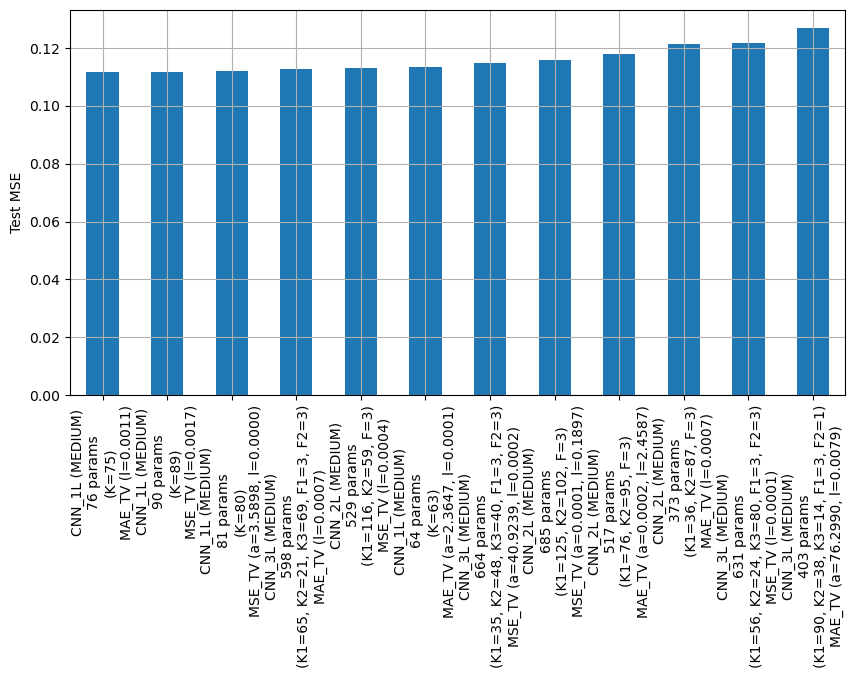

In [26]:
def get_test_mse_bar_plot(df_test_mse, title=None):

    f, ax = plt.subplots(figsize=(10, 5))
    ax = df_test_mse.metric.plot.bar()
    ax.set_xticklabels(
        df_test_mse.model,
        rotation=90,
        ha="center"
    )
    ax.set_ylabel('Test MSE')
    ax.set_title(title)
    ax.grid()

    return f

df_test = pd.concat([test_cnn_MAE, test_cnn_MSE]).sort_values(by='metric')
display(df_test.loc[df_test.model.str.contains('MEDIUM')])

f = get_test_mse_bar_plot(df_test.loc[df_test.model.str.contains('MEDIUM')])

### LSTM W5 Analysis

In [10]:
# Deprecated since architecture of RNNDeconvolutionRNN has been changed (added LayerNorm layer)
results_df = pd.read_csv(f'csv_logs/lstm_logs_W5.csv')
analyse_hp_search(results_df, sim_test_dataset, top_k=3)

/tmp/ipykernel_1162535/2580961473.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_models = logs.loc[logs.groupby('study_name').apply(lambda x: x.nsmallest(top_k, 'min_mse_val')).index.get_level_values(1)]
/home/assaraf/.conda/envs/mip_proj/lib/python3.10/site-packages/torch/nn/modules/rnn.py:62: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


RuntimeError: Error(s) in loading state_dict for RNNDeconvolutionRNN:
	Missing key(s) in state_dict: "kernel_rnn.layer_norm.weight", "kernel_rnn.layer_norm.bias". 

## W6

### CNN W6 Analysis

In [ ]:
sim_test_dataset = torch.load('datasets/simulated_data_zero_100m.pt')['test']
results_df = pd.read_csv('csv_logs/cnn_logs_W6.csv')
results_df.study_name.unique()

array(['CNN_3l_SimDataZERO_blocky=True_20250327_112255',
       'CNN_3l_SimDataZERO_blocky=False_20250327_182945',
       'CNN_4l_SimDataZERO_blocky=True_20250328_014959',
       'CNN_4l_SimDataZERO_blocky=False_20250328_094605'], dtype=object)

/tmp/ipykernel_978062/4117753079.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_models = logs.loc[logs.groupby('study_name').apply(lambda x: x.nsmallest(top_k, 'min_mse_val')).index.get_level_values(1)]


,model,metric,var
0,"CNN_4L (ZERO)\n3046 params\n(K1=61, K2=81, K3=...",0.019619,0.000001
2,"CNN_4L (ZERO)\n1345 params\n(K1=23, K2=31, K3=...",0.019734,0.000001
1,"CNN_3L (ZERO)\n1849 params\n(K1=53, K2=38, K3=...",0.019746,0.000001
3,"CNN_3L (ZERO)\n1411 params\n(K1=43, K2=28, K3=...",0.019866,0.000001


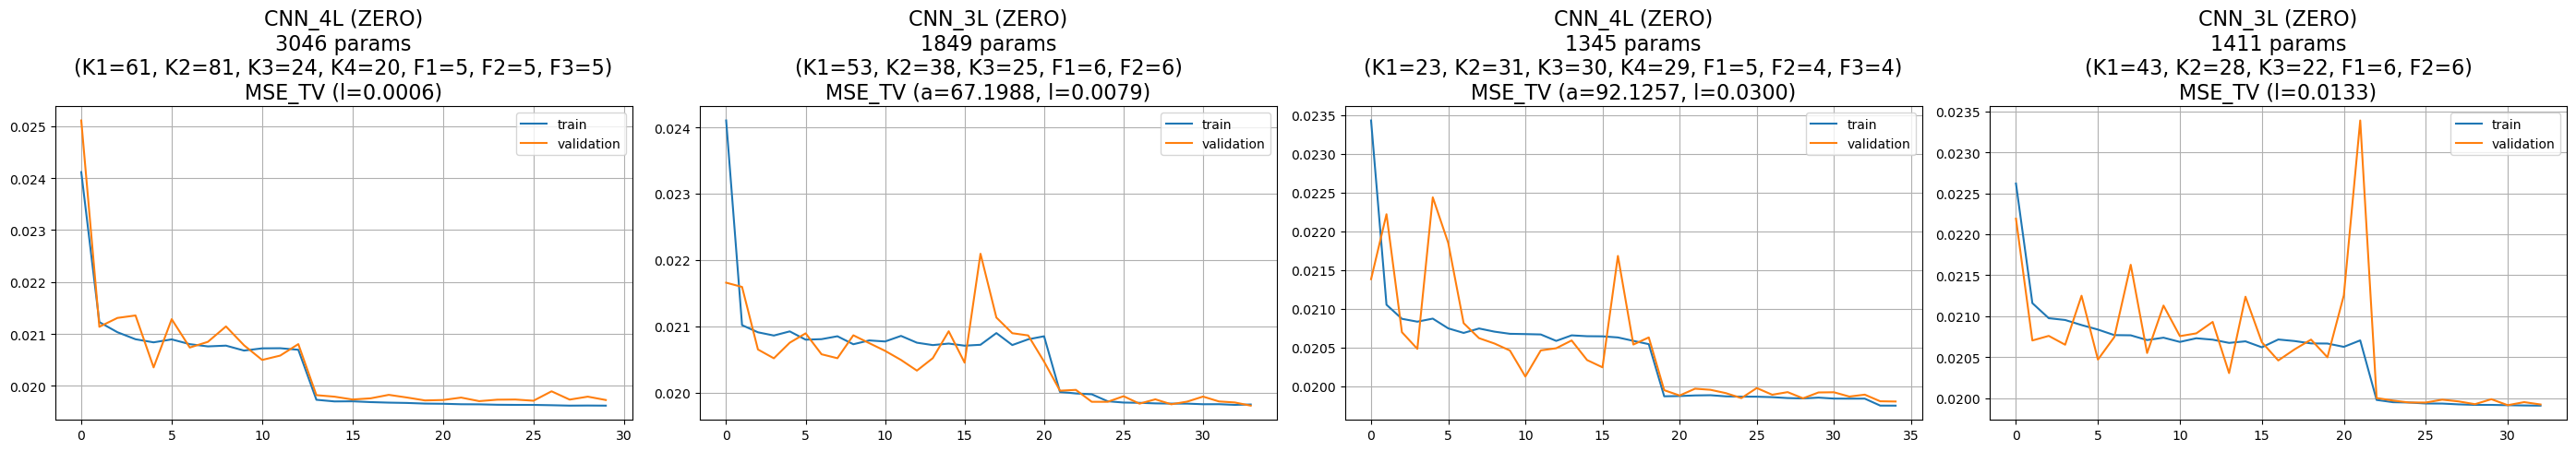

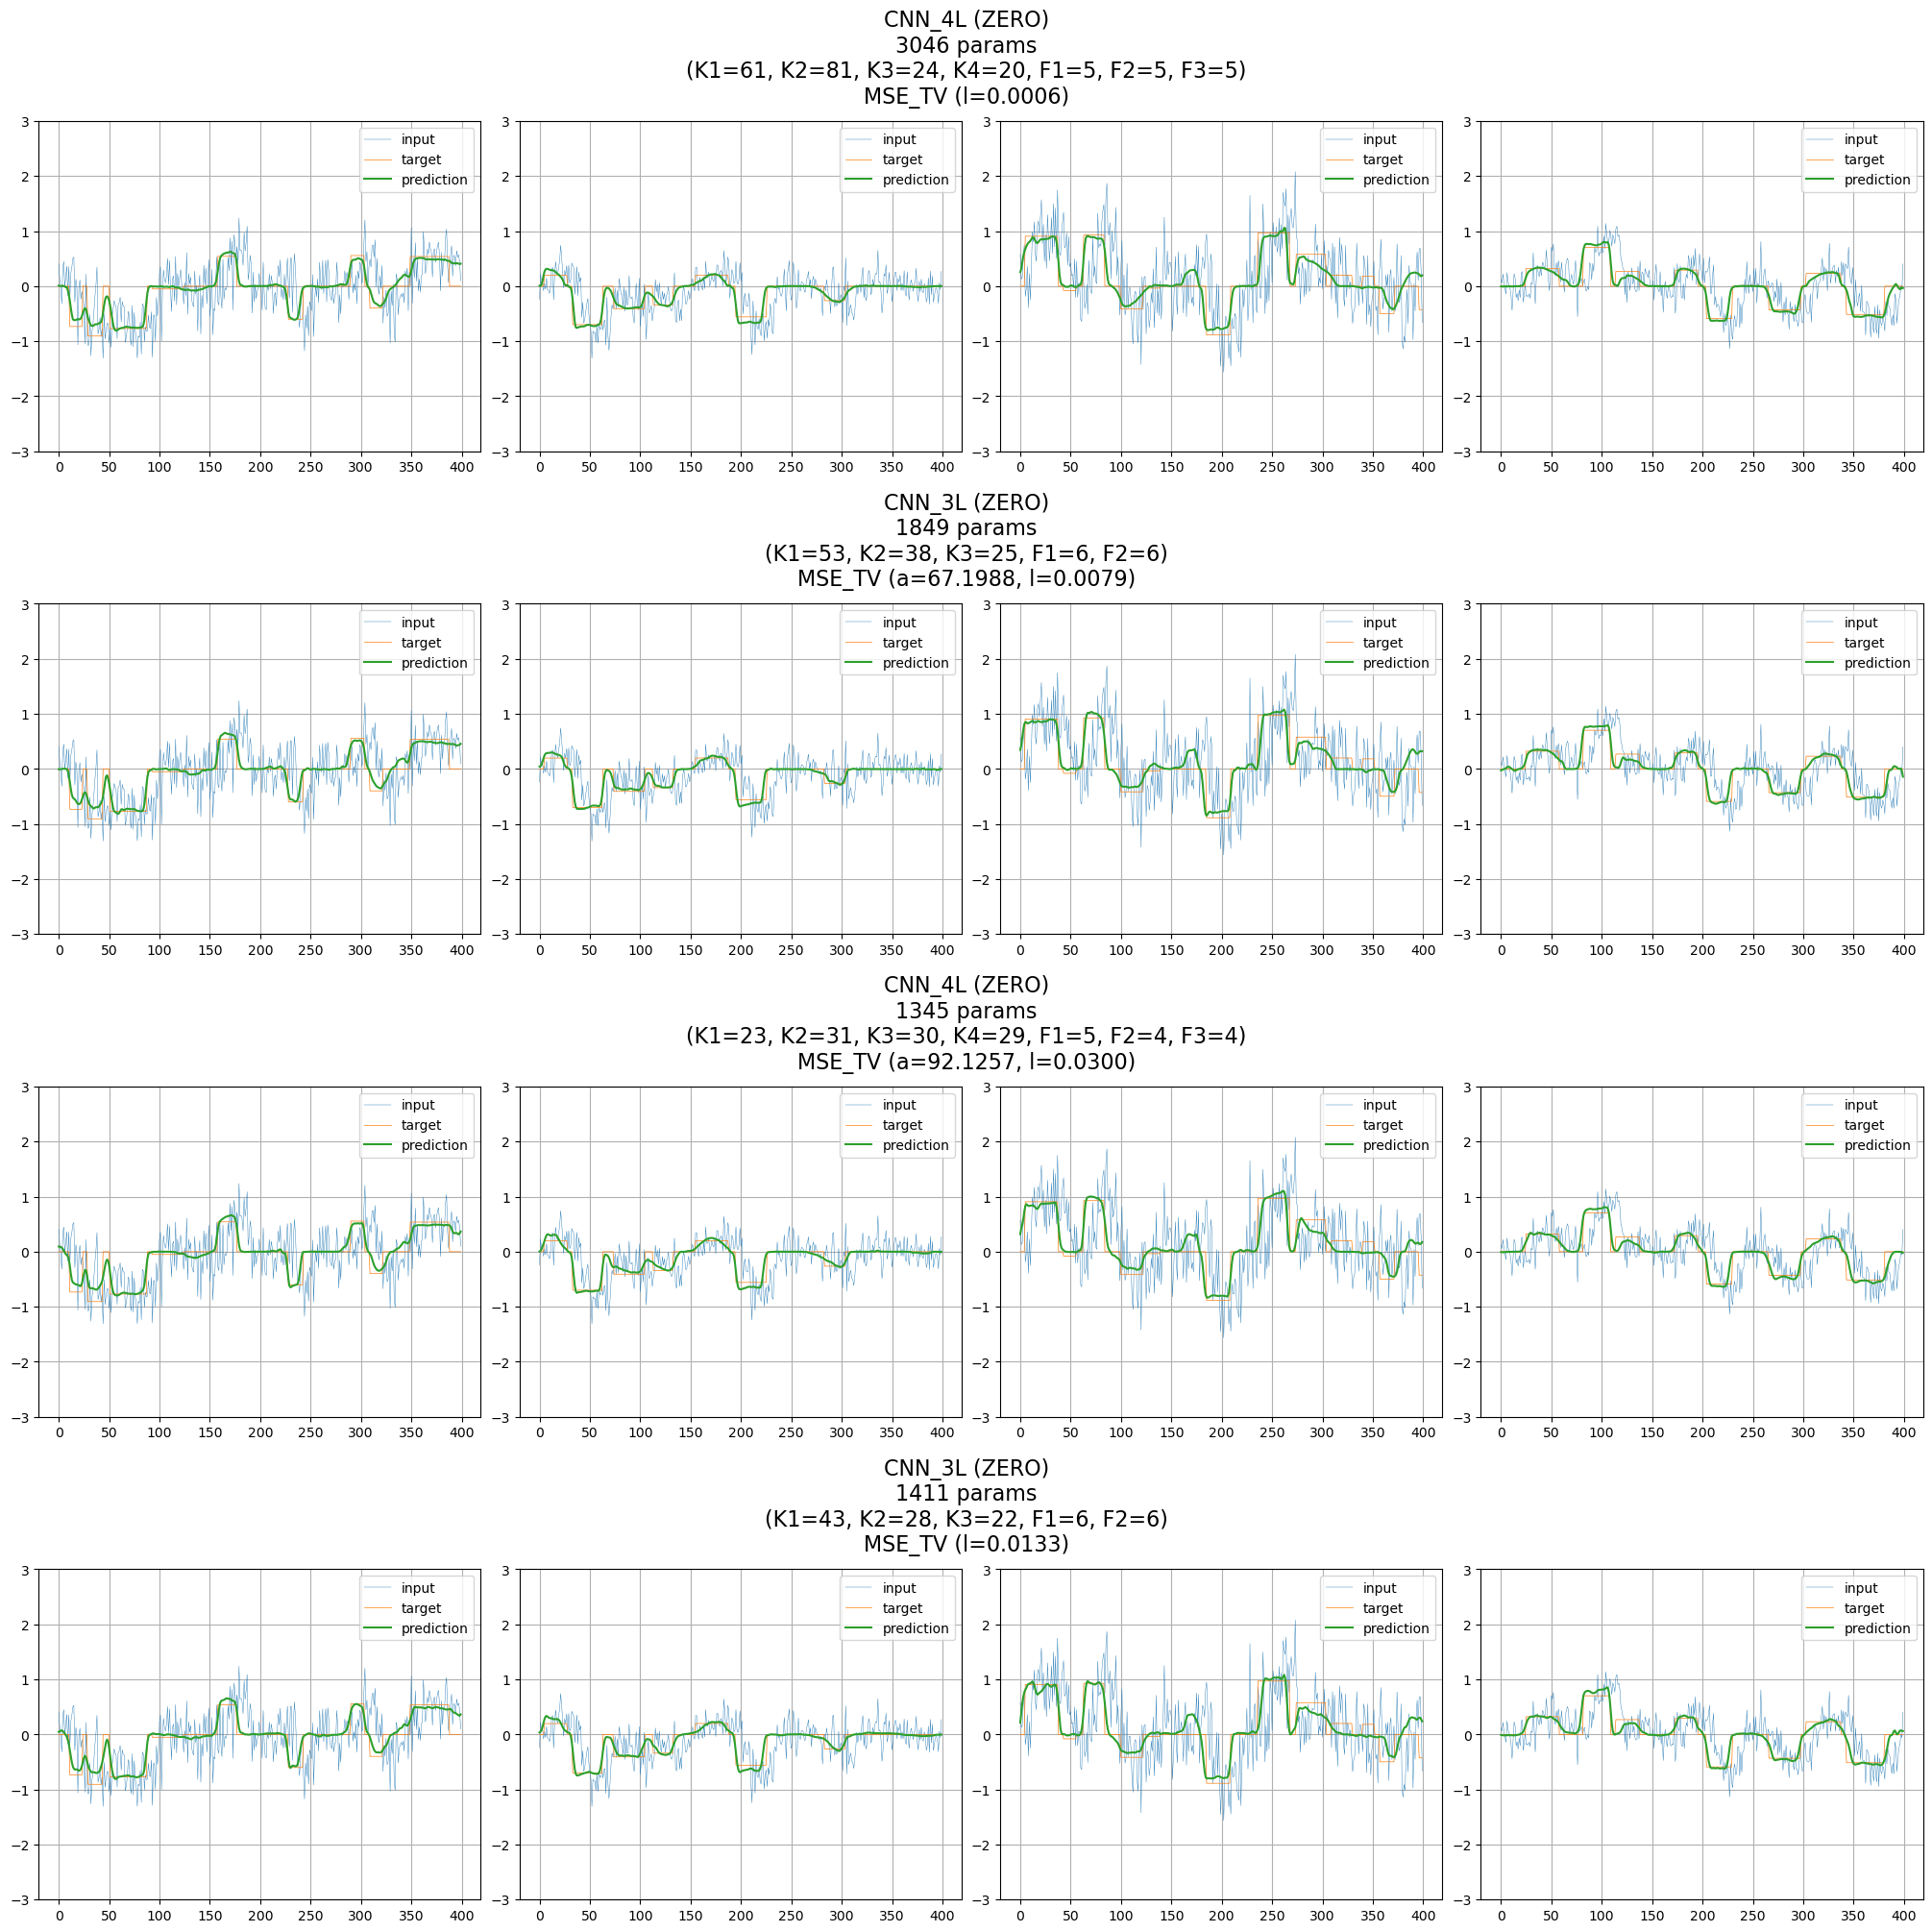

In [16]:
results_cnn = {}
results_cnn['loss_plot'], results_cnn['inference_plot'], results_cnn['df_test_mse'] = analyse_hp_search(results_df, sim_test_dataset)

/tmp/ipykernel_2806311/1415835022.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_models = logs.loc[logs.groupby('study_name').apply(lambda x: x.nsmallest(top_k, 'min_mse_val')).index.get_level_values(1)]


,model,metric,var
0,"CNN_4L (NEW)\n3046 params\n(K1=61, K2=81, K3=2...",0.248828,0.004514
3,"CNN_3L (NEW)\n1411 params\n(K1=43, K2=28, K3=2...",0.283799,0.006222
1,"CNN_3L (NEW)\n1849 params\n(K1=53, K2=38, K3=2...",0.295537,0.006420
2,"CNN_4L (NEW)\n1345 params\n(K1=23, K2=31, K3=3...",0.306605,0.007420


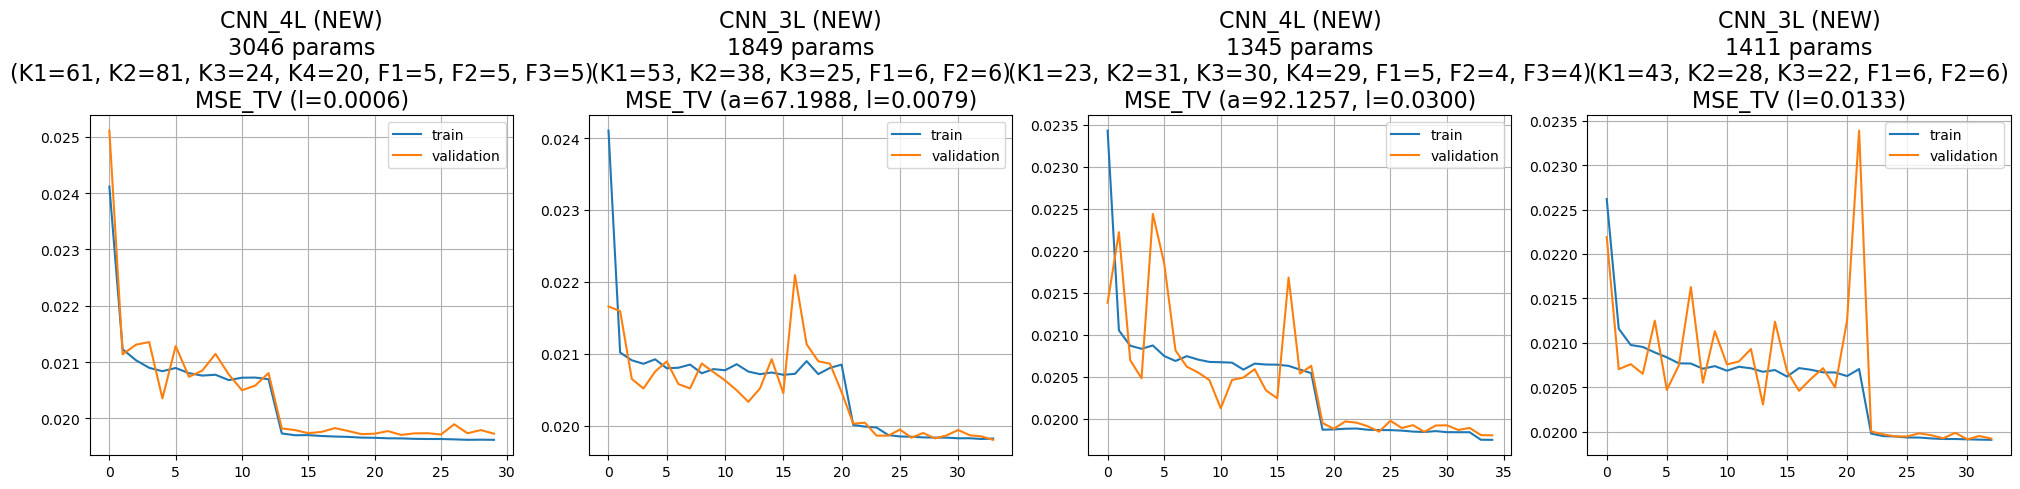

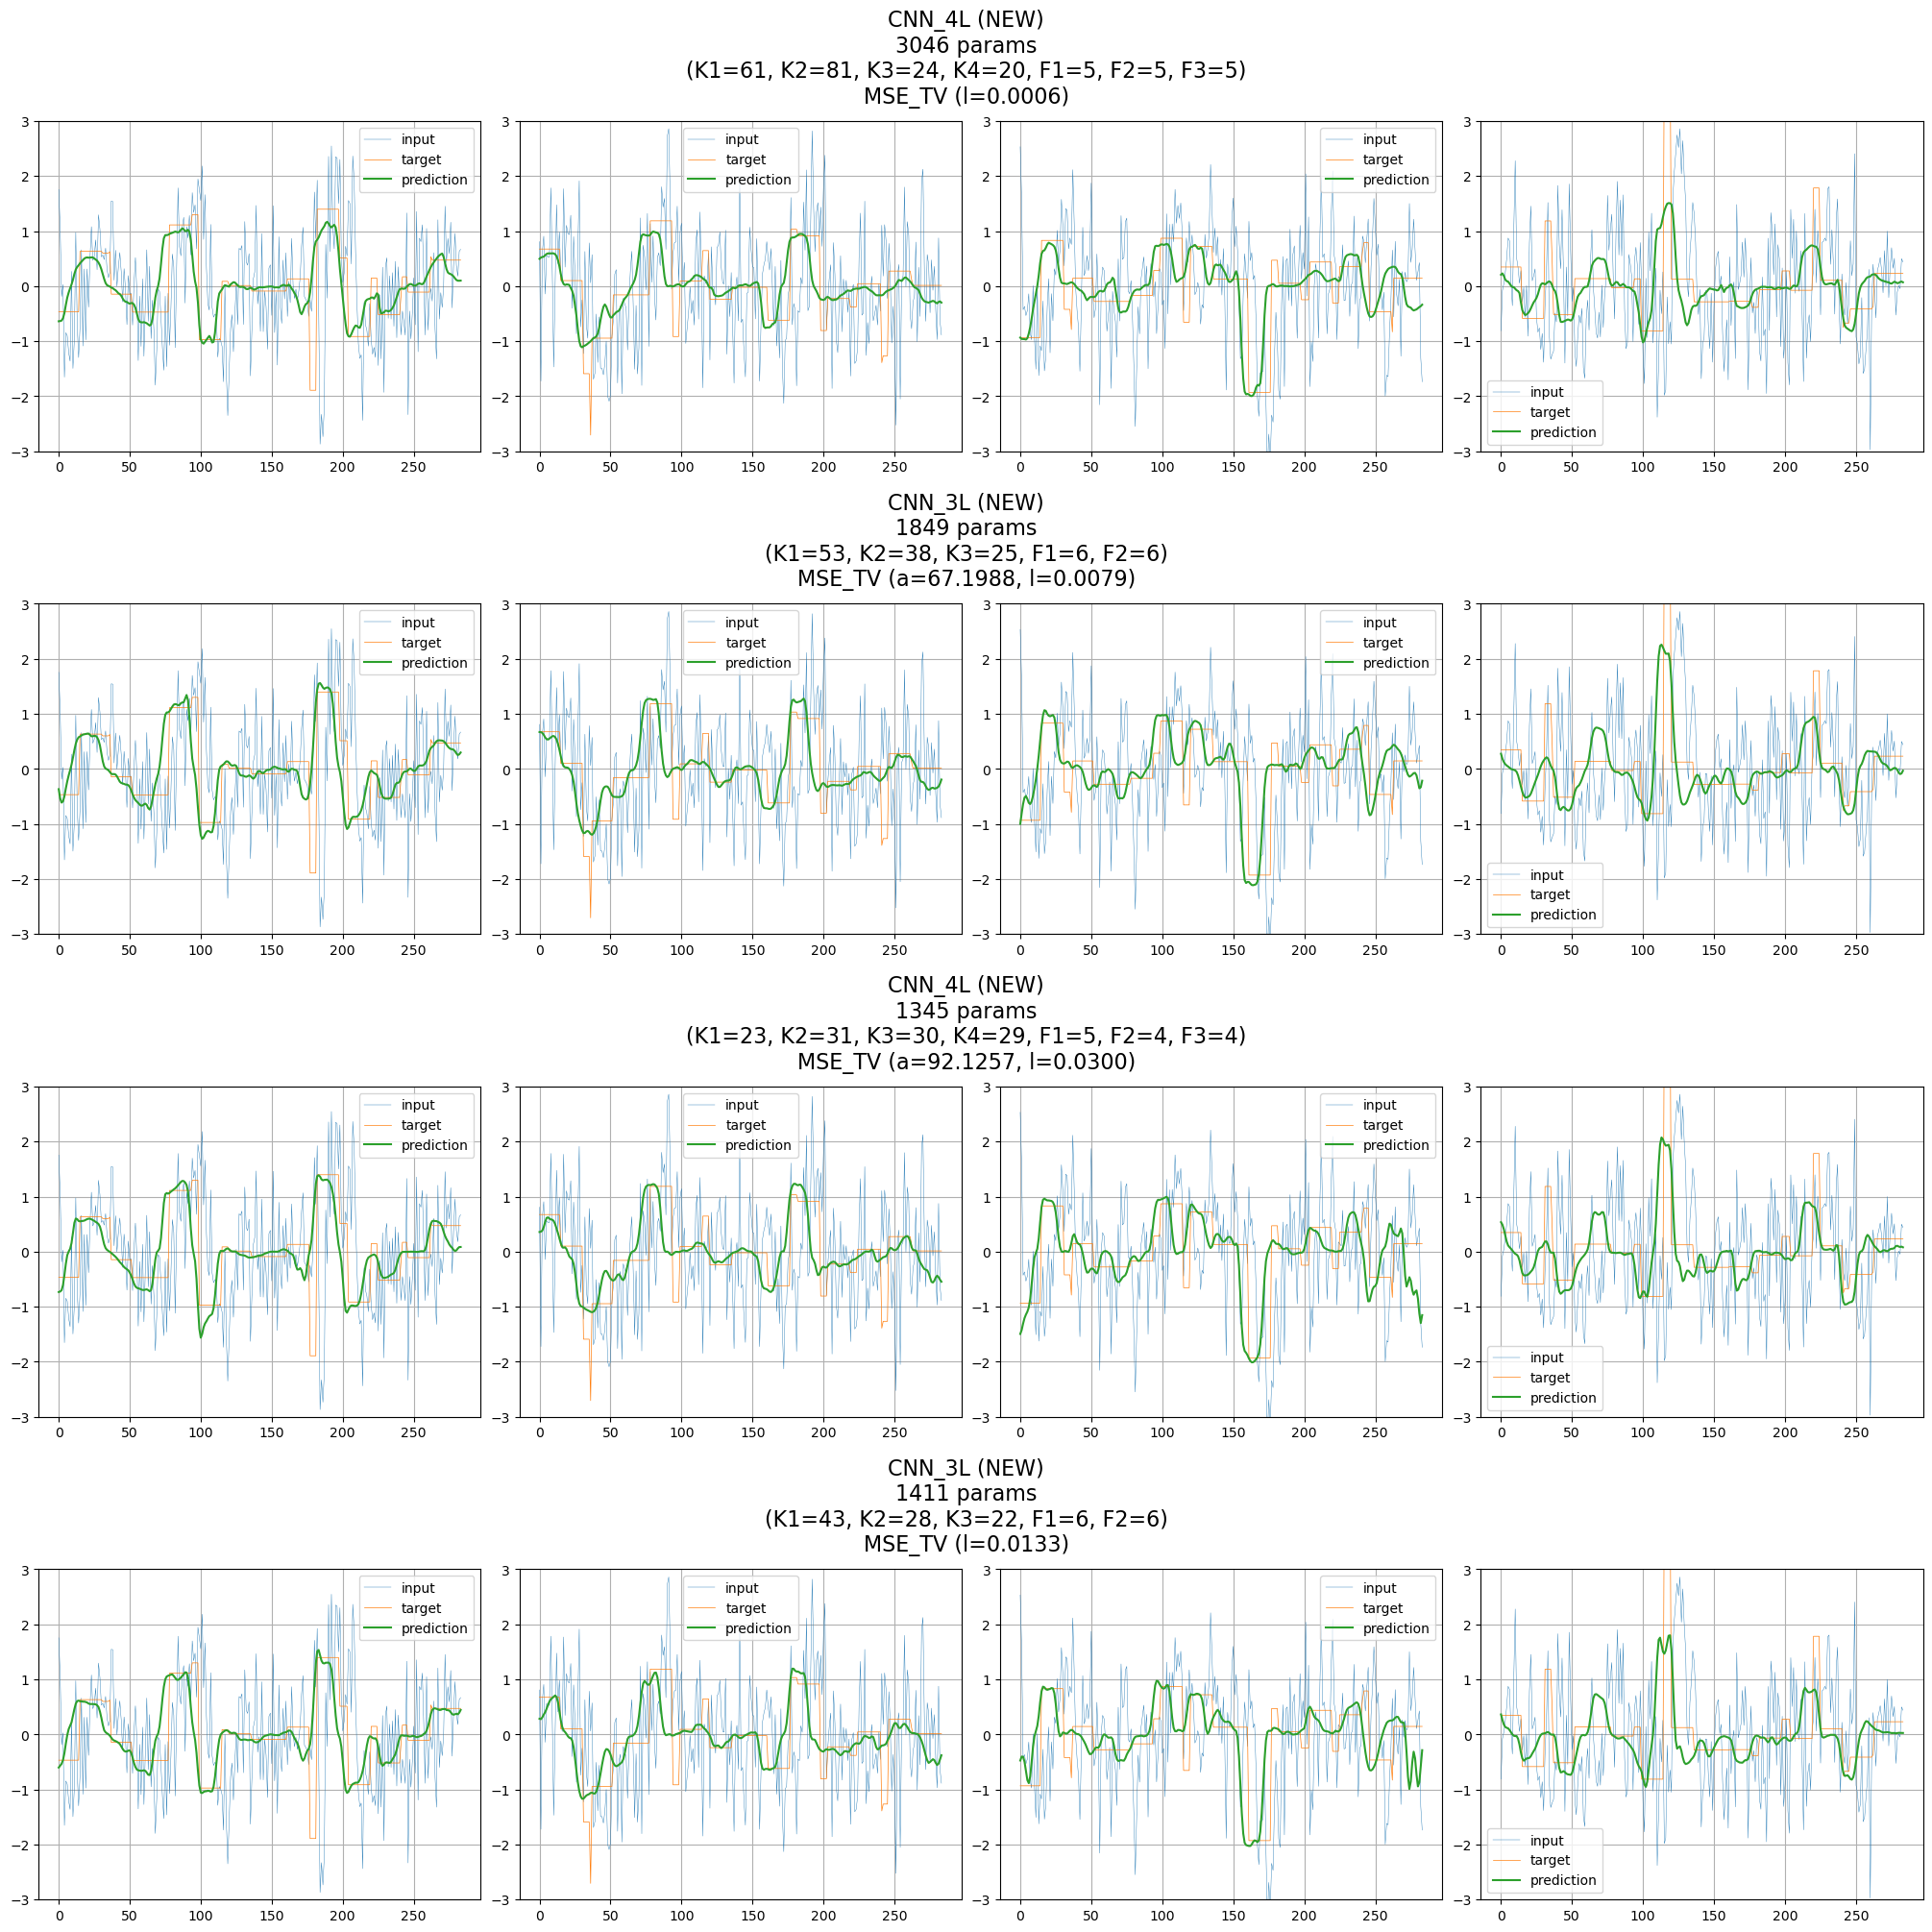

In [9]:
loss_plot, inference_plot, df_test_mse = analyse_hp_search(results_df, real_test_dataset)

### LSTM W6 Analysis

In [ ]:
sim_test_dataset = torch.load('datasets/simulated_data_zero_100m.pt')['test']
results_df = pd.read_csv(f'csv_logs/lstm_logs_W6.csv')
results_df

,study_name,timecode,model_name,n_params,train_size,validation_size,test_size,min_mse_val,test_mse,test_mse_var,lr,batch_size,patience,tolerance,architecture
0,LSTMDeconvLSTM_SimDataZERO_blocky=True_2025032...,20250327_112602,LSTMDeconvLSTM_1lK_hiddenK=43_3lO_hiddenO=59_k...,79638,210000,45000,45000,0.084726,0.087113,0.000015,0.01,64,10,0.0001,RNNDeconvolutionRNN(\n (kernel_rnn): KernelRN...
1,LSTMDeconvLSTM_SimDataZERO_blocky=True_2025032...,20250327_113344,LSTMDeconvLSTM_1lK_hiddenK=60_2lO_hiddenO=59_k...,58984,210000,45000,45000,0.069422,0.070543,0.000011,0.01,64,10,0.0001,RNNDeconvolutionRNN(\n (kernel_rnn): KernelRN...
2,LSTMDeconvLSTM_SimDataZERO_blocky=True_2025032...,20250327_114328,LSTMDeconvLSTM_1lK_hiddenK=34_1lO_hiddenO=24_k...,9467,210000,45000,45000,0.020536,0.021450,0.000001,0.01,64,10,0.0001,RNNDeconvolutionRNN(\n (kernel_rnn): KernelRN...
3,LSTMDeconvLSTM_SimDataZERO_blocky=True_2025032...,20250327_115450,LSTMDeconvLSTM_2lK_hiddenK=60_1lO_hiddenO=57_k...,61064,210000,45000,45000,0.019819,0.035228,0.000002,0.01,64,10,0.0001,RNNDeconvolutionRNN(\n (kernel_rnn): KernelRN...
4,LSTMDeconvLSTM_SimDataZERO_blocky=True_2025032...,20250327_120600,LSTMDeconvLSTM_2lK_hiddenK=16_1lO_hiddenO=21_k...,6244,210000,45000,45000,0.020603,0.020759,0.000002,0.01,64,10,0.0001,RNNDeconvolutionRNN(\n (kernel_rnn): KernelRN...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,LSTMDeconvLSTM_SimDataZERO_blocky=False_202503...,20250328_225046,LSTMDeconvLSTM_2lK_hiddenK=37_1lO_hiddenO=63_k...,36484,210000,45000,45000,0.019708,NaN,NaN,0.01,64,10,0.0001,RNNDeconvolutionRNN(\n (kernel_rnn): KernelRN...
196,LSTMDeconvLSTM_SimDataZERO_blocky=False_202503...,20250328_230213,LSTMDeconvLSTM_2lK_hiddenK=31_3lO_hiddenO=62_k...,93229,210000,45000,45000,0.018530,0.024143,0.000002,0.01,64,10,0.0001,RNNDeconvolutionRNN(\n (kernel_rnn): KernelRN...
197,LSTMDeconvLSTM_SimDataZERO_blocky=False_202503...,20250328_230910,LSTMDeconvLSTM_2lK_hiddenK=27_3lO_hiddenO=64_k...,95163,210000,45000,45000,0.019126,NaN,NaN,0.01,64,10,0.0001,RNNDeconvolutionRNN(\n (kernel_rnn): KernelRN...
198,LSTMDeconvLSTM_SimDataZERO_blocky=False_202503...,20250328_232036,LSTMDeconvLSTM_2lK_hiddenK=30_3lO_hiddenO=62_k...,92154,210000,45000,45000,0.019061,NaN,NaN,0.01,64,10,0.0001,RNNDeconvolutionRNN(\n (kernel_rnn): KernelRN...


/tmp/ipykernel_1162535/2580961473.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_models = logs.loc[logs.groupby('study_name').apply(lambda x: x.nsmallest(top_k, 'min_mse_val')).index.get_level_values(1)]


,model,metric,var
0,"LSTMDeconvLSTM (ZERO)\n86238 params\n(3L(K), 4...",0.018445,0.000001
1,"LSTMDeconvLSTM (ZERO)\n93229 params\n(2L(K), 3...",0.024380,0.000003


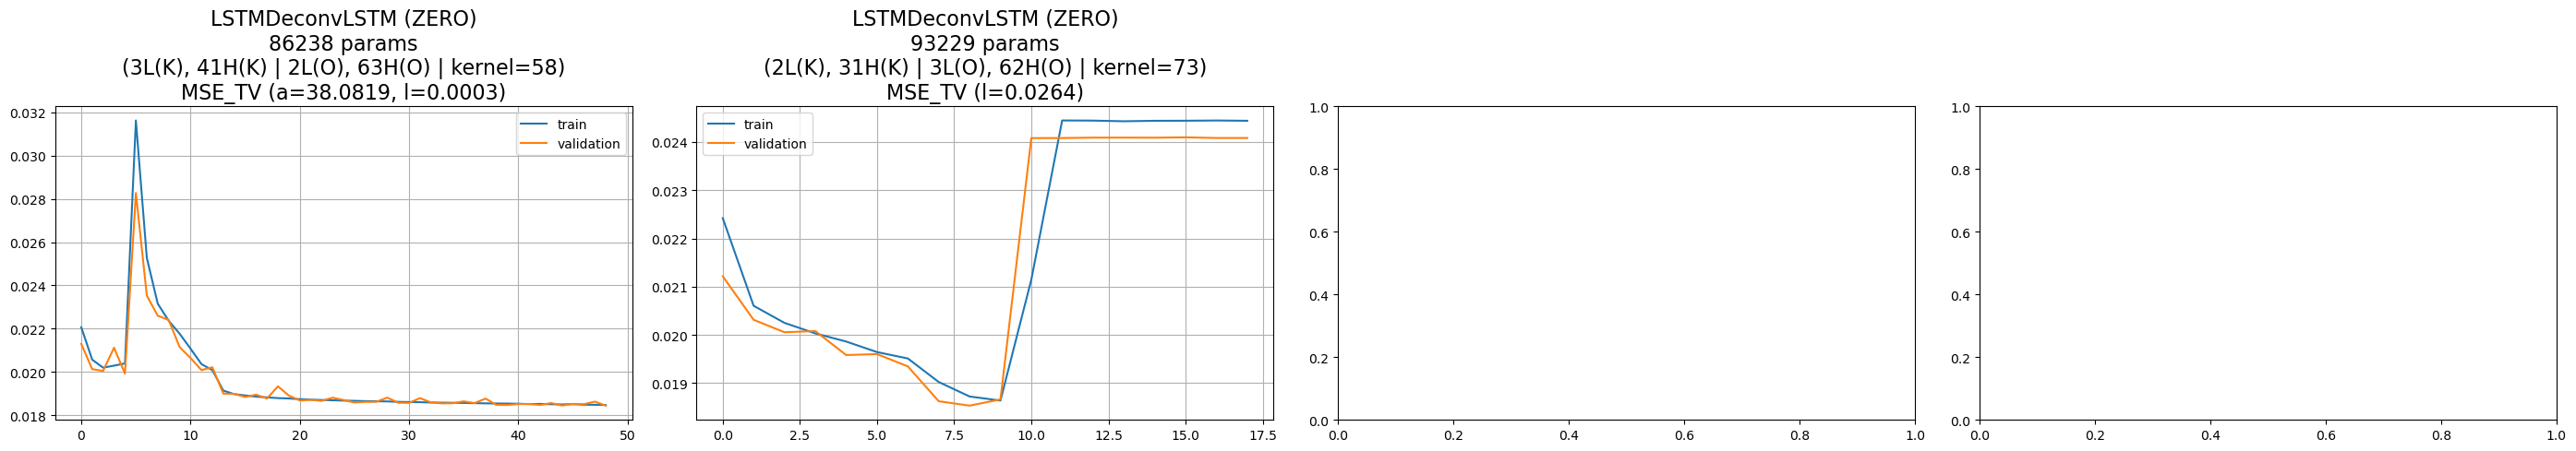

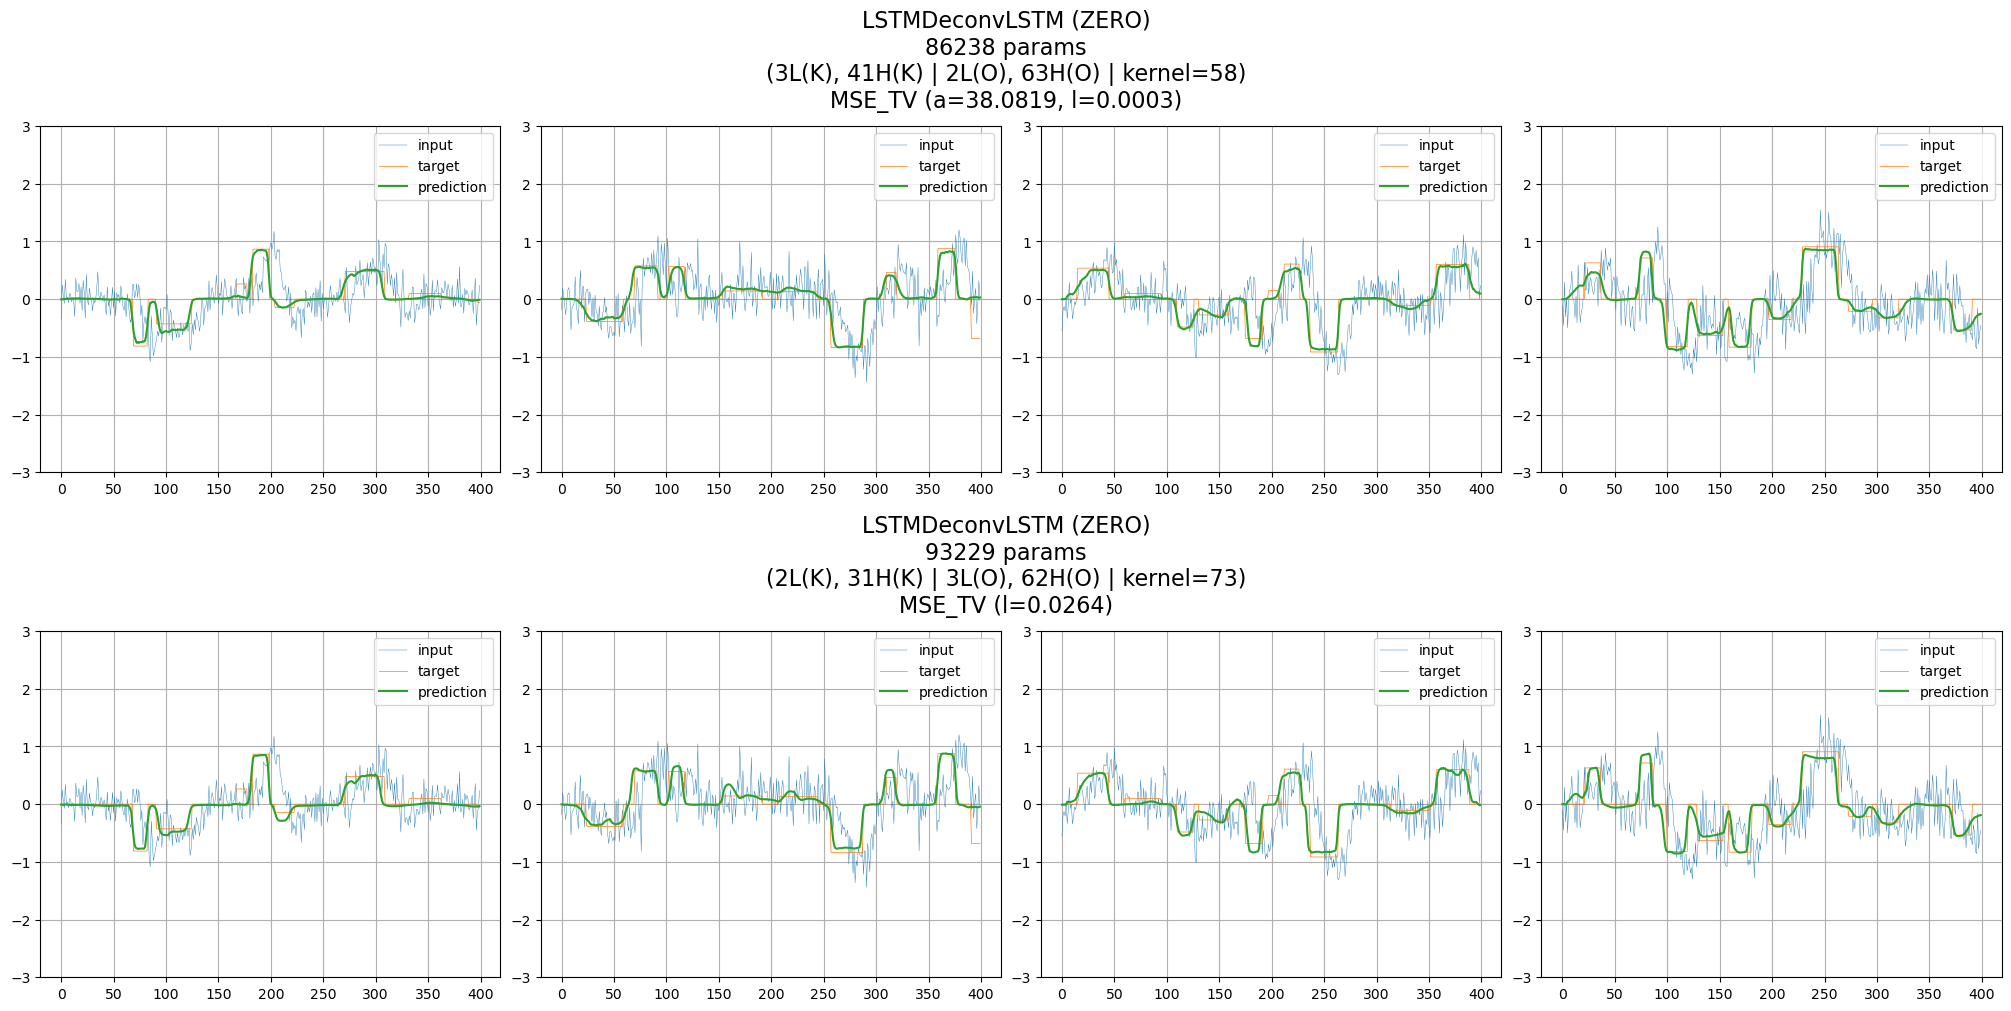

In [9]:
results_lstm = {}
results_lstm['loss_plot'], results_lstm['inference_plot'], results_lstm['df_test_mse'] = analyse_hp_search(results_df, sim_test_dataset, top_k=1)

In [45]:
#analyse_hp_search(results_df, real_data_test, top_k=2)

### Extra plots

In [ ]:
def get_test_mse_bar_plot(df_test_mse, title=None):

    f, ax = plt.subplots(figsize=(10, 5))
    ax = df_test_mse.metric.plot.bar()
    ax.set_xticklabels(
        df_test_mse.model,
        rotation=90,
        ha="center"
    )
    ax.set_ylabel('Test MSE')
    ax.set_title(title)
    ax.grid()

    return f

,model,metric,var
0,"LSTMDeconvLSTM (ZERO)\n86238 params\n(3L(K), 4...",0.018447,0.000001
3,"LSTMDeconvLSTM (ZERO)\n75764 params\n(3L(K), 4...",0.018639,0.000001
0,"CNN_4L (ZERO)\n3046 params\n(K1=61, K2=81, K3=...",0.019619,0.000001
2,"CNN_4L (ZERO)\n1345 params\n(K1=23, K2=31, K3=...",0.019734,0.000001
1,"CNN_3L (ZERO)\n1849 params\n(K1=53, K2=38, K3=...",0.019746,0.000001
3,"CNN_3L (ZERO)\n1411 params\n(K1=43, K2=28, K3=...",0.019866,0.000001
2,"LSTMDeconvLSTM (ZERO)\n60533 params\n(2L(K), 3...",0.022353,0.000002
1,"LSTMDeconvLSTM (ZERO)\n93229 params\n(2L(K), 3...",0.024367,0.000003


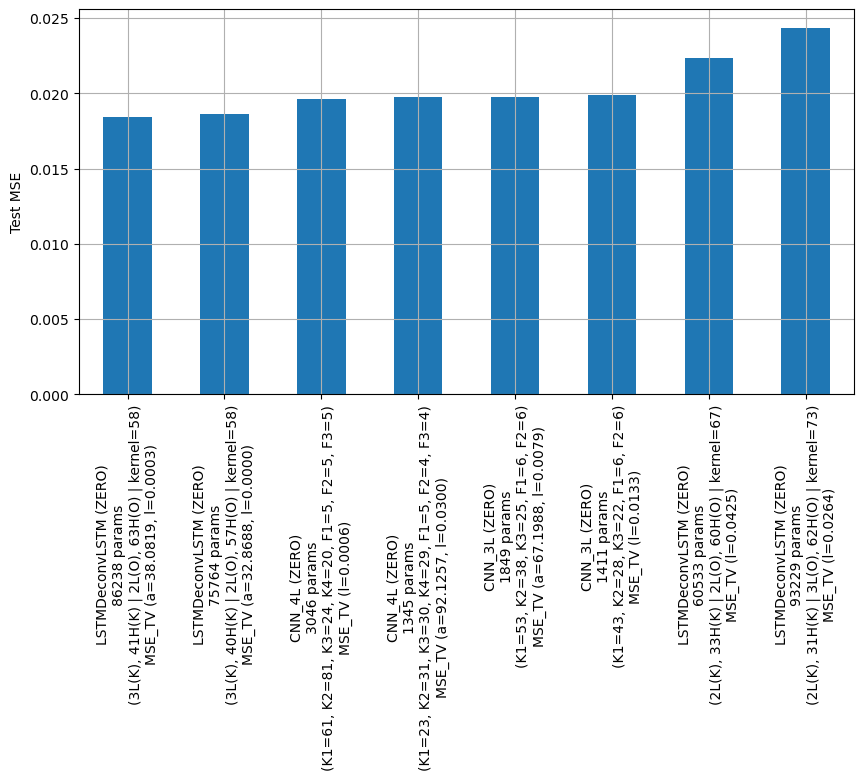

In [21]:
df_test = pd.concat([results_cnn['df_test_mse'], results_lstm['df_test_mse']]).sort_values(by='metric')
display(df_test)

f = get_test_mse_bar_plot(df_test)

In [5]:
best_models.shape

(41, 19)

/tmp/ipykernel_2462218/609088746.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_models = logs.loc[logs.groupby('study_name').apply(lambda x: x.nsmallest(top_k, 'min_mse_val')).index.get_level_values(1)]
/tmp/ipykernel_2462218/609088746.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_models = logs.loc[logs.groupby('study_name').apply(lambda x: x.nsmallest(top_k, 'min_mse_val')).index.get

Text(0.5, 1.0, 'hrf = 32s')

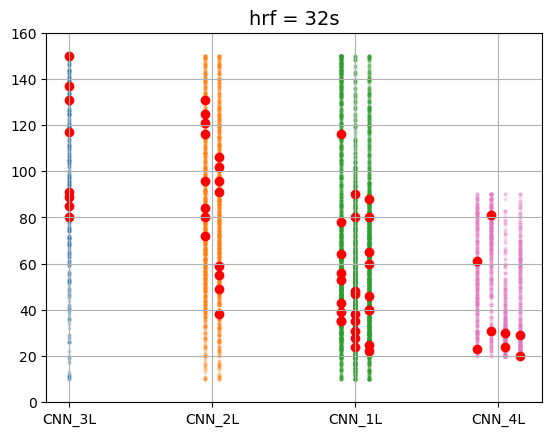

In [7]:
cnn_logs_w5 = pd.read_csv('csv_logs/cnn_logs_W5.csv')
cnn_logs_w5 = add_formatted_model_name(cnn_logs_w5)
cnn_logs_w5.architecture_dict = cnn_logs_w5.architecture_dict.map(lambda x: [int(val) for key, val in x.items() if key[0] == 'k'])

cnn_logs_w6 = pd.read_csv('csv_logs/cnn_logs_W6_new.csv')
cnn_logs_w6 = add_formatted_model_name(cnn_logs_w6)
cnn_logs_w6.architecture_dict = cnn_logs_w6.architecture_dict.map(lambda x: [int(val) for key, val in x.items() if key[0] == 'k'])

best_models_w5 = get_best_models_df(cnn_logs_w5)
best_models_w5 = add_formatted_model_name(best_models_w5)
best_models_w5.architecture_dict = best_models_w5.architecture_dict.map(lambda x: [int(val) for key, val in x.items() if key[0] == 'k'])

best_models_w6 = get_best_models_df(cnn_logs_w6)
best_models_w6 = add_formatted_model_name(best_models_w6)
best_models_w6.architecture_dict = best_models_w6.architecture_dict.map(lambda x: [int(val) for key, val in x.items() if key[0] == 'k'])

cnn_logs = pd.concat([cnn_logs_w5, cnn_logs_w6])
best_models = pd.concat([best_models_w5, best_models_w6])

kernel_sizes_all = {
    cnn_type: np.array(cnn_logs.loc[cnn_logs.model_type == cnn_type].architecture_dict.to_list()).squeeze()
    for cnn_type in cnn_logs.model_type.unique()
}

kernel_sizes_best = {
    cnn_type: np.array(best_models.loc[best_models.model_type == cnn_type].architecture_dict.to_list()).squeeze()
    for cnn_type in best_models.model_type.unique()
}

plt.scatter(np.ones(kernel_sizes_all['CNN_1L'].shape), kernel_sizes_all['CNN_1L'], c='tab:blue', s=4, alpha=0.2)
plt.scatter(np.ones(kernel_sizes_all['CNN_2L'].shape)*np.array([1.95, 2.05]), kernel_sizes_all['CNN_2L'], c='tab:orange', s=4, alpha=0.2)
plt.scatter(np.ones(kernel_sizes_all['CNN_3L'].shape)*np.array([2.9, 3., 3.1]), kernel_sizes_all['CNN_3L'], c='tab:green', s=4, alpha=0.2)
plt.scatter(np.ones(kernel_sizes_all['CNN_4L'].shape)*np.array([3.85, 3.95, 4.05, 4.15]), kernel_sizes_all['CNN_4L'], c='tab:pink', s=4, alpha=0.2)

plt.scatter(np.ones(kernel_sizes_best['CNN_1L'].shape), kernel_sizes_best['CNN_1L'], c='r')
plt.scatter(np.ones(kernel_sizes_best['CNN_2L'].shape)*np.array([1.95, 2.05]), kernel_sizes_best['CNN_2L'], c='r')
plt.scatter(np.ones(kernel_sizes_best['CNN_3L'].shape)*np.array([2.9, 3., 3.1]), kernel_sizes_best['CNN_3L'], c='r')
plt.scatter(np.ones(kernel_sizes_best['CNN_4L'].shape)*np.array([3.85, 3.95, 4.05, 4.15]), kernel_sizes_best['CNN_4L'], c='r')

plt.ylim([0, 160])
plt.grid()
plt.xticks(range(1, len(kernel_sizes_best.keys())+1), kernel_sizes_best.keys())
plt.title(r'hrf = 32s', fontsize=14)

## W9

### AE

In [ ]:
# dataset = torch.load('datasets/simulated_data_bob_300m.pt')['test']
dataset = torch.load('datasets/real_data_MGL_080808.pt')['test']
results_df = pd.read_csv('csv_logs/ae_logs_W9.csv')
results_df['signal_length'] = len(dataset[0][0])
results_df = results_df.loc[results_df.study_name.isin([study for study in results_df.study_name.unique() if 'RealDataMGL' in study])]
results_df.shape

(25, 16)

/tmp/ipykernel_1162535/2580961473.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_models = logs.loc[logs.groupby('study_name').apply(lambda x: x.nsmallest(top_k, 'min_mse_val')).index.get_level_values(1)]
/tmp/ipykernel_1162535/2580961473.py:209: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  f.tight_layout()


,model,metric,var
0,AutoEncoder(CNN_4L) (aMGL)\n232179 params\n(C=...,0.052107,0.001414
1,AutoEncoder(CNN_4L) (aMGL)\n181881 params\n(C=...,0.053366,0.001269
3,AutoEncoder(CNN_3L) (aMGL)\n202177 params\n(C=...,0.119341,0.001214
2,AutoEncoder(CNN_3L) (aMGL)\n277596 params\n(C=...,0.127292,0.001407


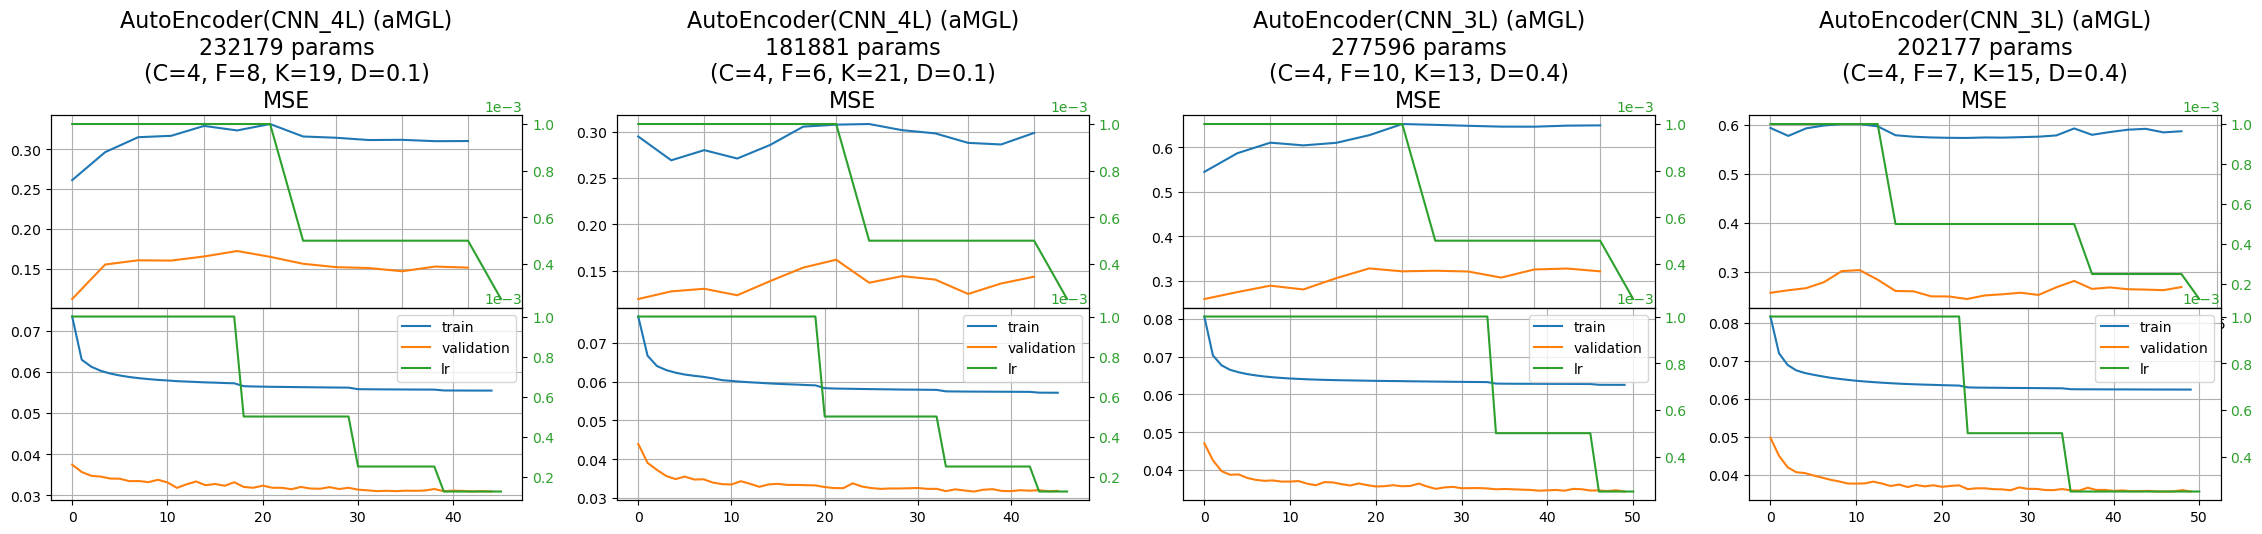

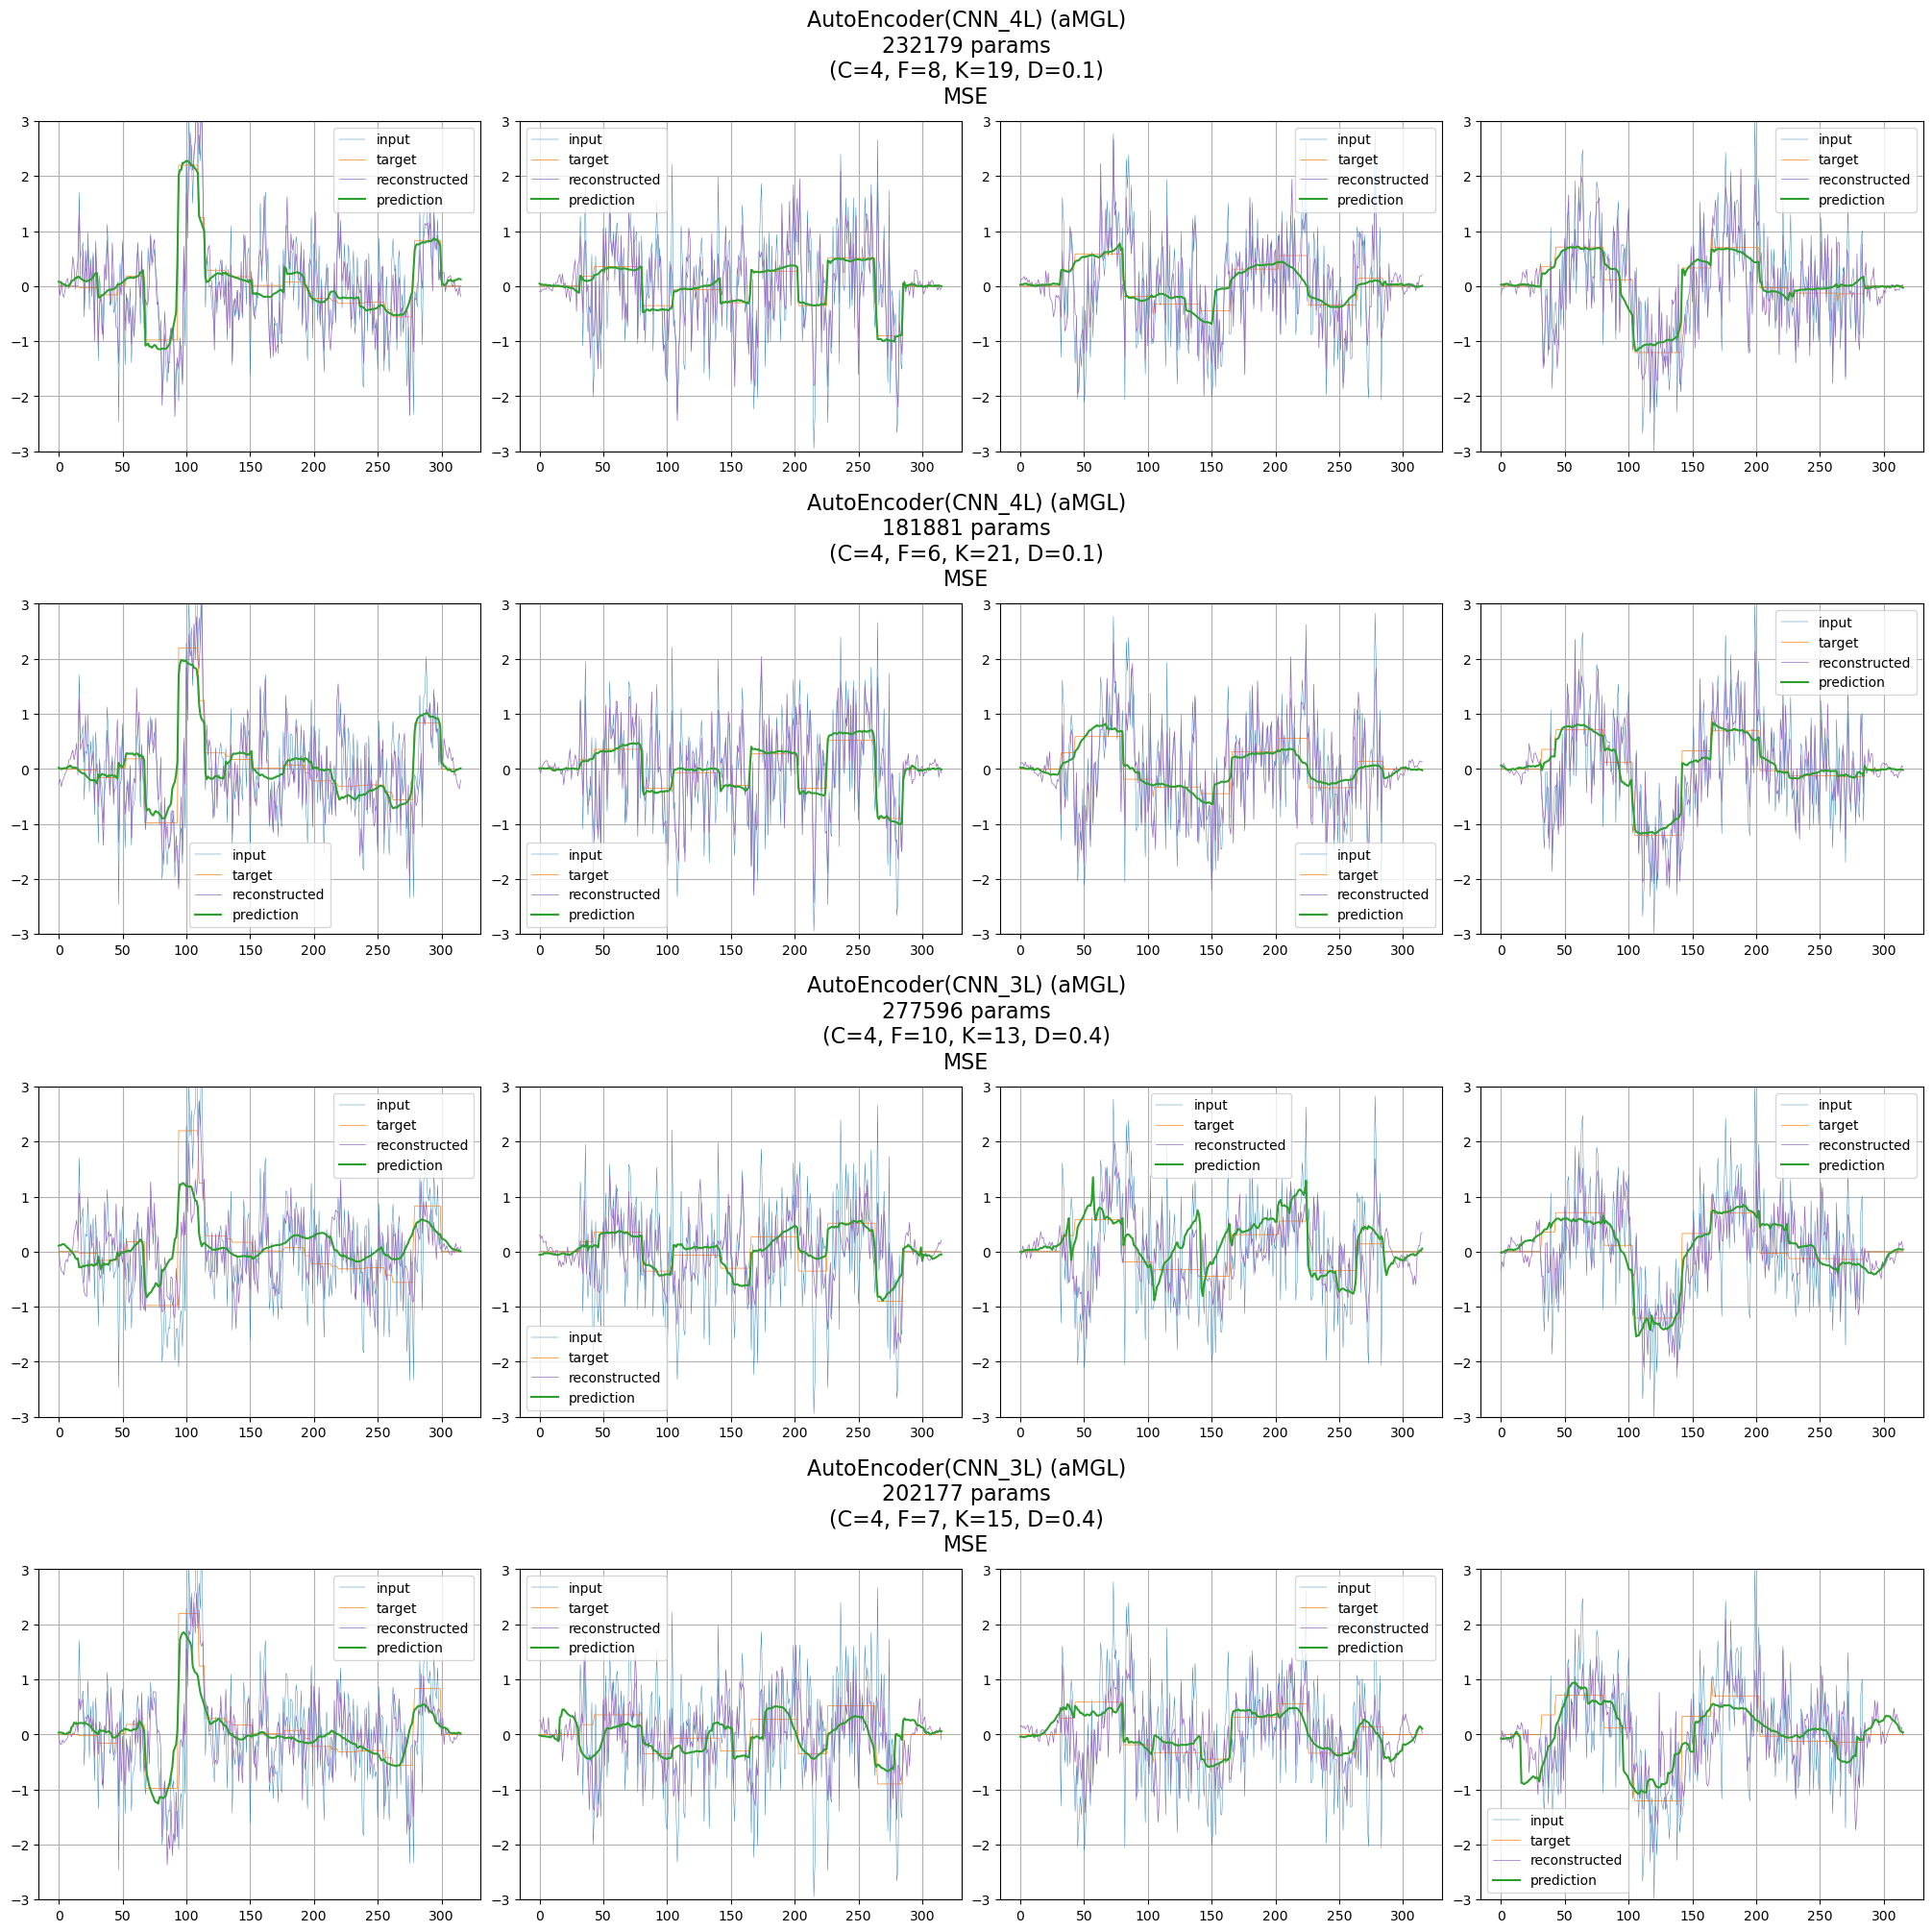

In [18]:
results_ae = {}
results_ae['loss_plot'], results_ae['inference_plot'], results_ae['df_test_mse'] = analyse_hp_search(results_df, dataset, top_k=2)

### CNN

In [ ]:
# dataset = torch.load('datasets/simulated_data_alice_300m.pt')['test']
dataset = torch.load('datasets/real_data_MGL_080808.pt')['test']
results_df = pd.read_csv('csv_logs/cnn_logs_W9.csv')
# results_df = results_df.loc[results_df.study_name == results_df.study_name.unique()[-1]]
results_df.shape

(702, 15)

/tmp/ipykernel_1036113/1423821458.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_models = logs.loc[logs.groupby('study_name').apply(lambda x: x.nsmallest(top_k, 'min_mse_val')).index.get_level_values(1)]


,model,metric,var
0,"CNN_3L (aMGL)\n38941 params\n(K1=39, K2=45, K3...",0.073097,0.001190
7,"CNN_3L (aMGL)\n16491 params\n(K1=24, K2=39, K3...",0.081512,0.001092
6,"CNN_2L (ALICE)\n1291 params\n(K1=50, K2=78, F=...",0.291554,0.004649
5,"CNN_2L (ALICE)\n2746 params\n(K1=35, K2=25, F=...",0.302288,0.005830
2,"CNN_3L (ALICE)\n19452 params\n(K1=25, K2=25, K...",0.307769,0.007412
4,"CNN_4L (ALICE)\n43304 params\n(K1=14, K2=15, K...",0.316842,0.008054
1,"CNN_4L (ALICE)\n10691 params\n(K1=35, K2=76, K...",0.324869,0.008576
3,"CNN_3L (ALICE)\n9821 params\n(K1=55, K2=88, K3...",0.326232,0.008186


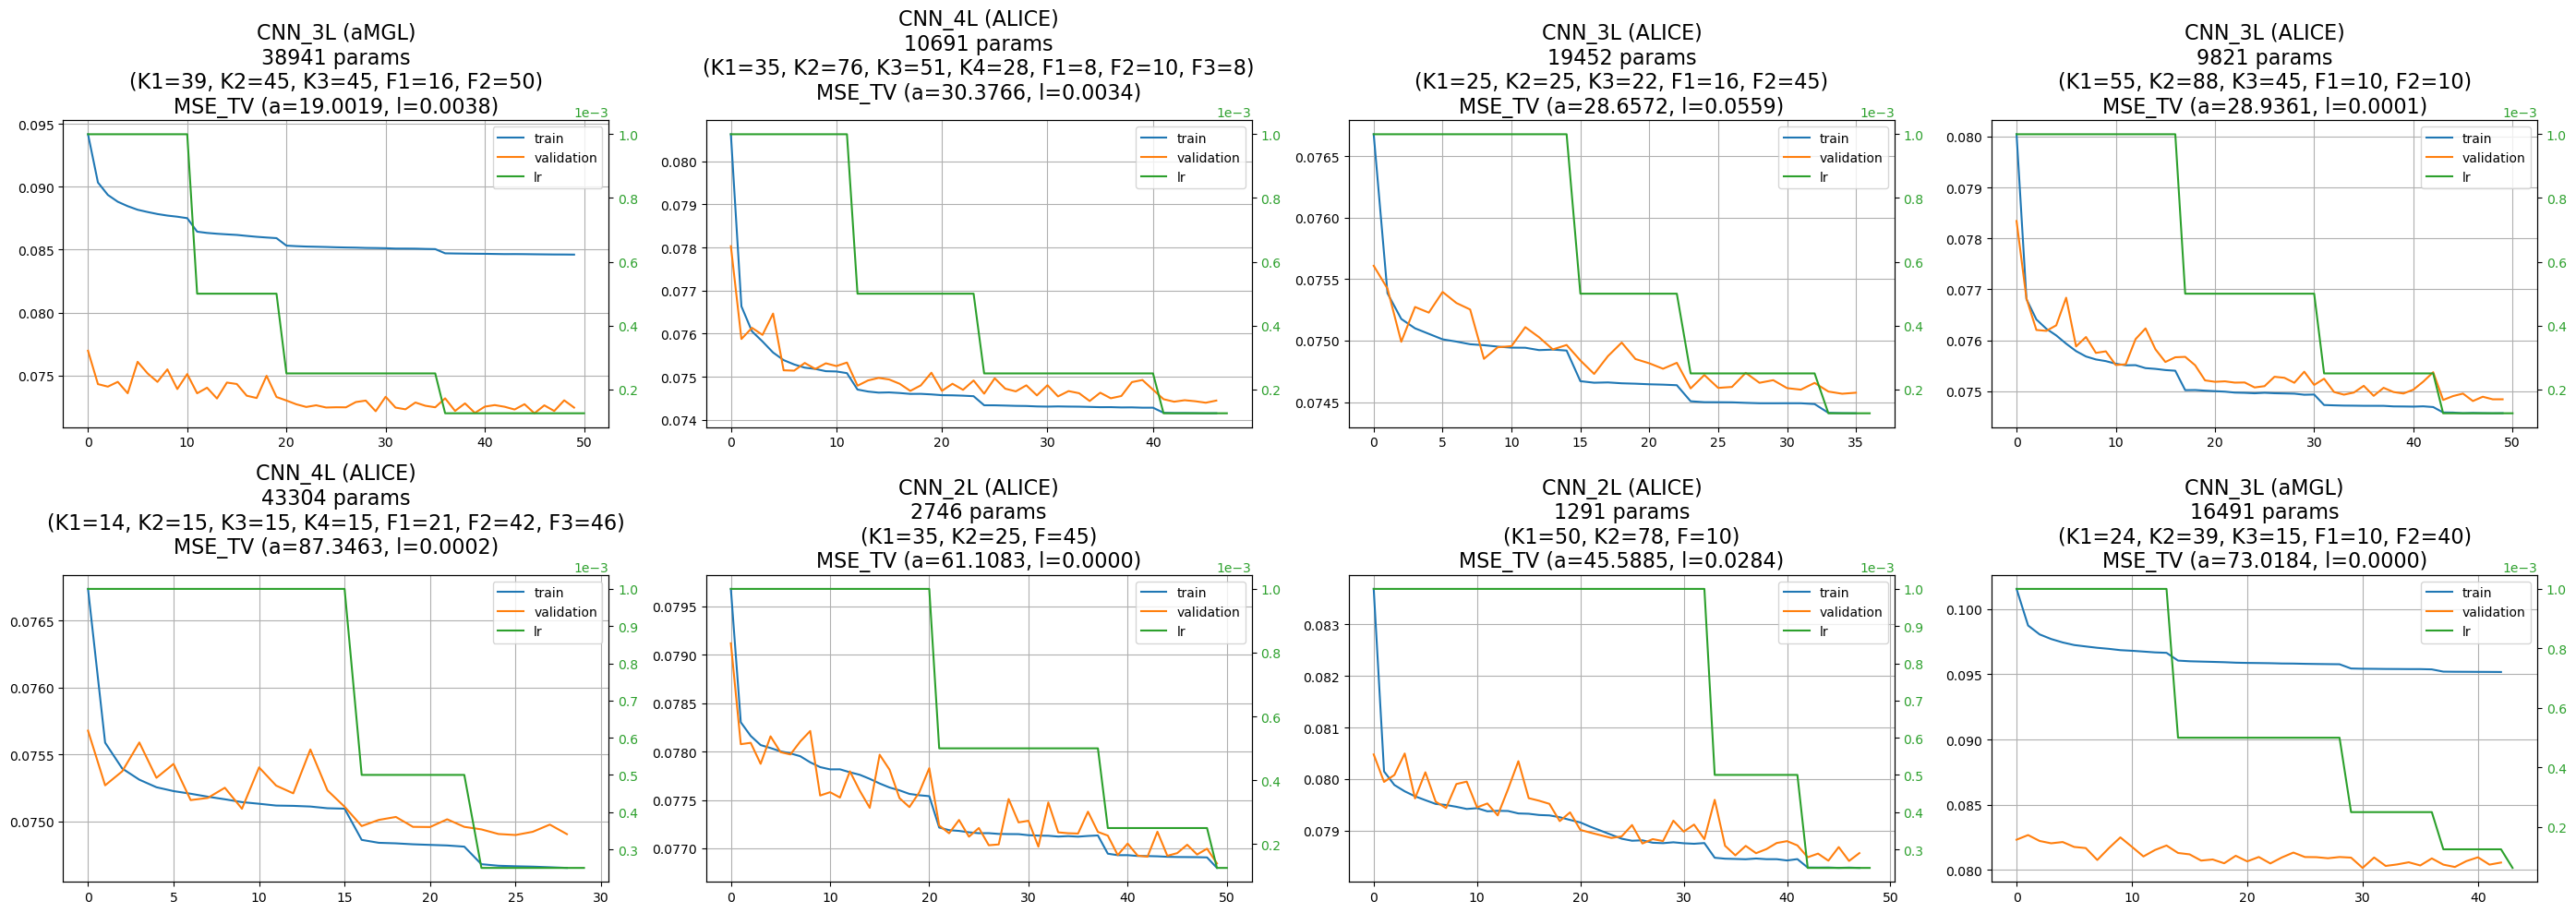

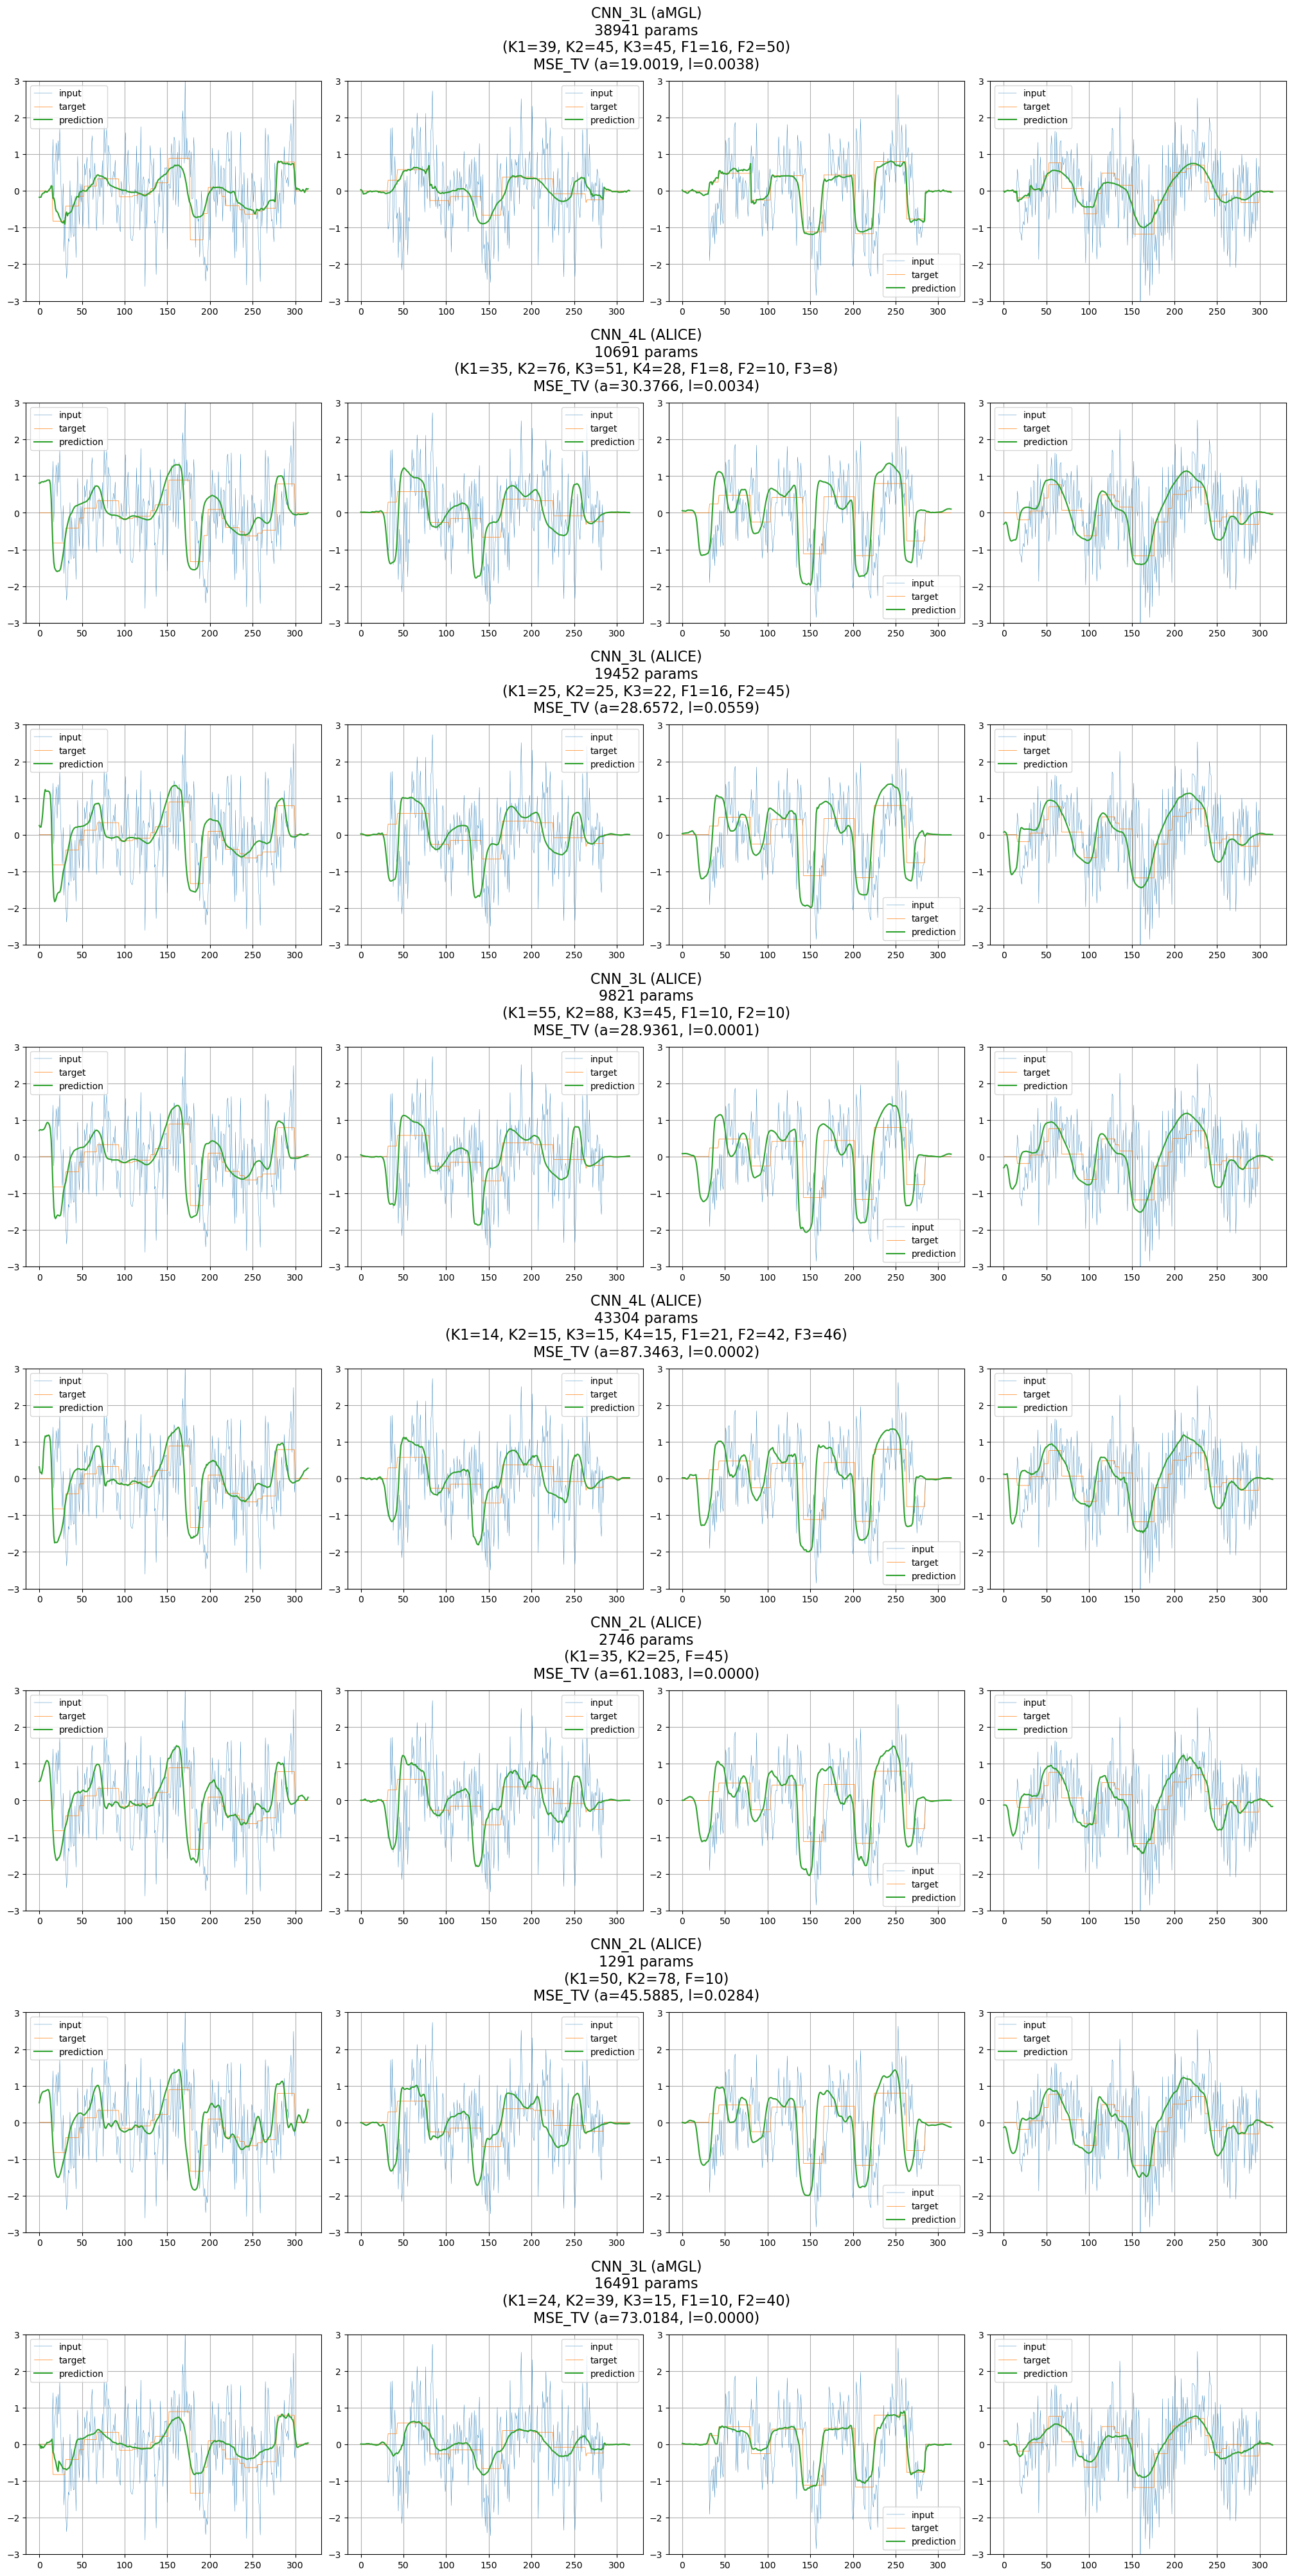

In [15]:
results_cnn = {}
results_cnn['loss_plot'], results_cnn['inference_plot'], results_cnn['df_test_mse'] = analyse_hp_search(results_df, dataset)

### LSTM

In [16]:
sim_test_dataset = torch.load('datasets/simulated_data_alice_300m.pt')['test']
results_df = pd.read_csv('csv_logs/lstm_logs_W9.csv')
results_df.shape

(108, 15)

/tmp/ipykernel_1036113/1423821458.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_models = logs.loc[logs.groupby('study_name').apply(lambda x: x.nsmallest(top_k, 'min_mse_val')).index.get_level_values(1)]
/home/assaraf/.conda/envs/mip_proj/lib/python3.10/site-packages/torch/nn/modules/rnn.py:62: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


,model,metric,var
0,"LSTMDeconvLSTM (ALICE)\n66026 params\n(2L(K), ...",0.073804,0.000027
1,"LSTMDeconvLSTM (ALICE)\n15918 params\n(1L(K), ...",0.074185,0.000028
2,"LSTMDeconvLSTM (BOB)\n27498 params\n(3L(K), 18...",0.145678,0.000066
3,"LSTM (ALICE)\n18871 params\n(3L, H=30)\nMSE_TV...",0.339358,0.000304
4,"LSTM (ALICE)\n3409 params\n(2L, H=16)\nMSE_TV ...",0.341419,0.000305
5,"LSTM (BOB)\n6274 params\n(3L, H=17)\nMSE_TV (a...",0.350457,0.000318


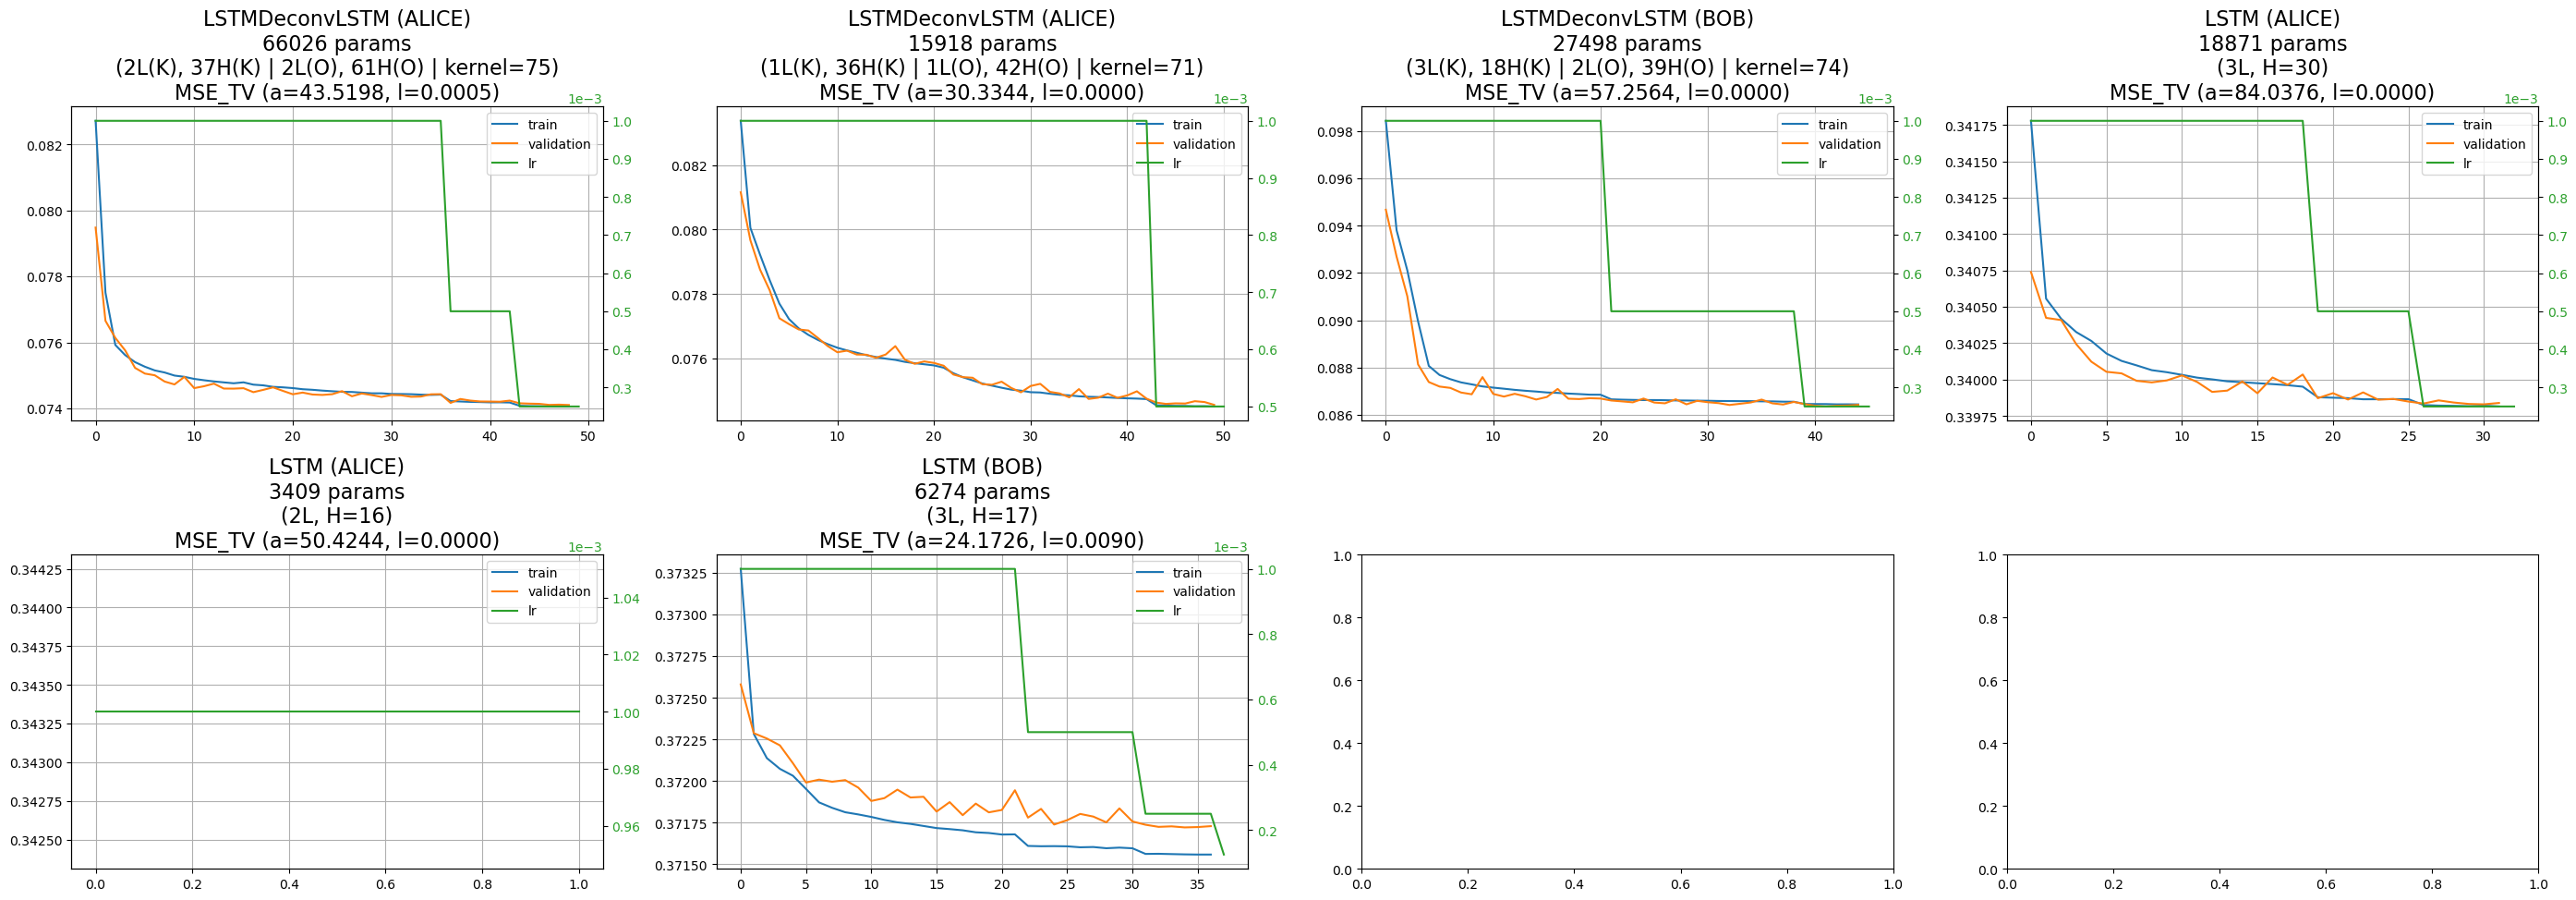

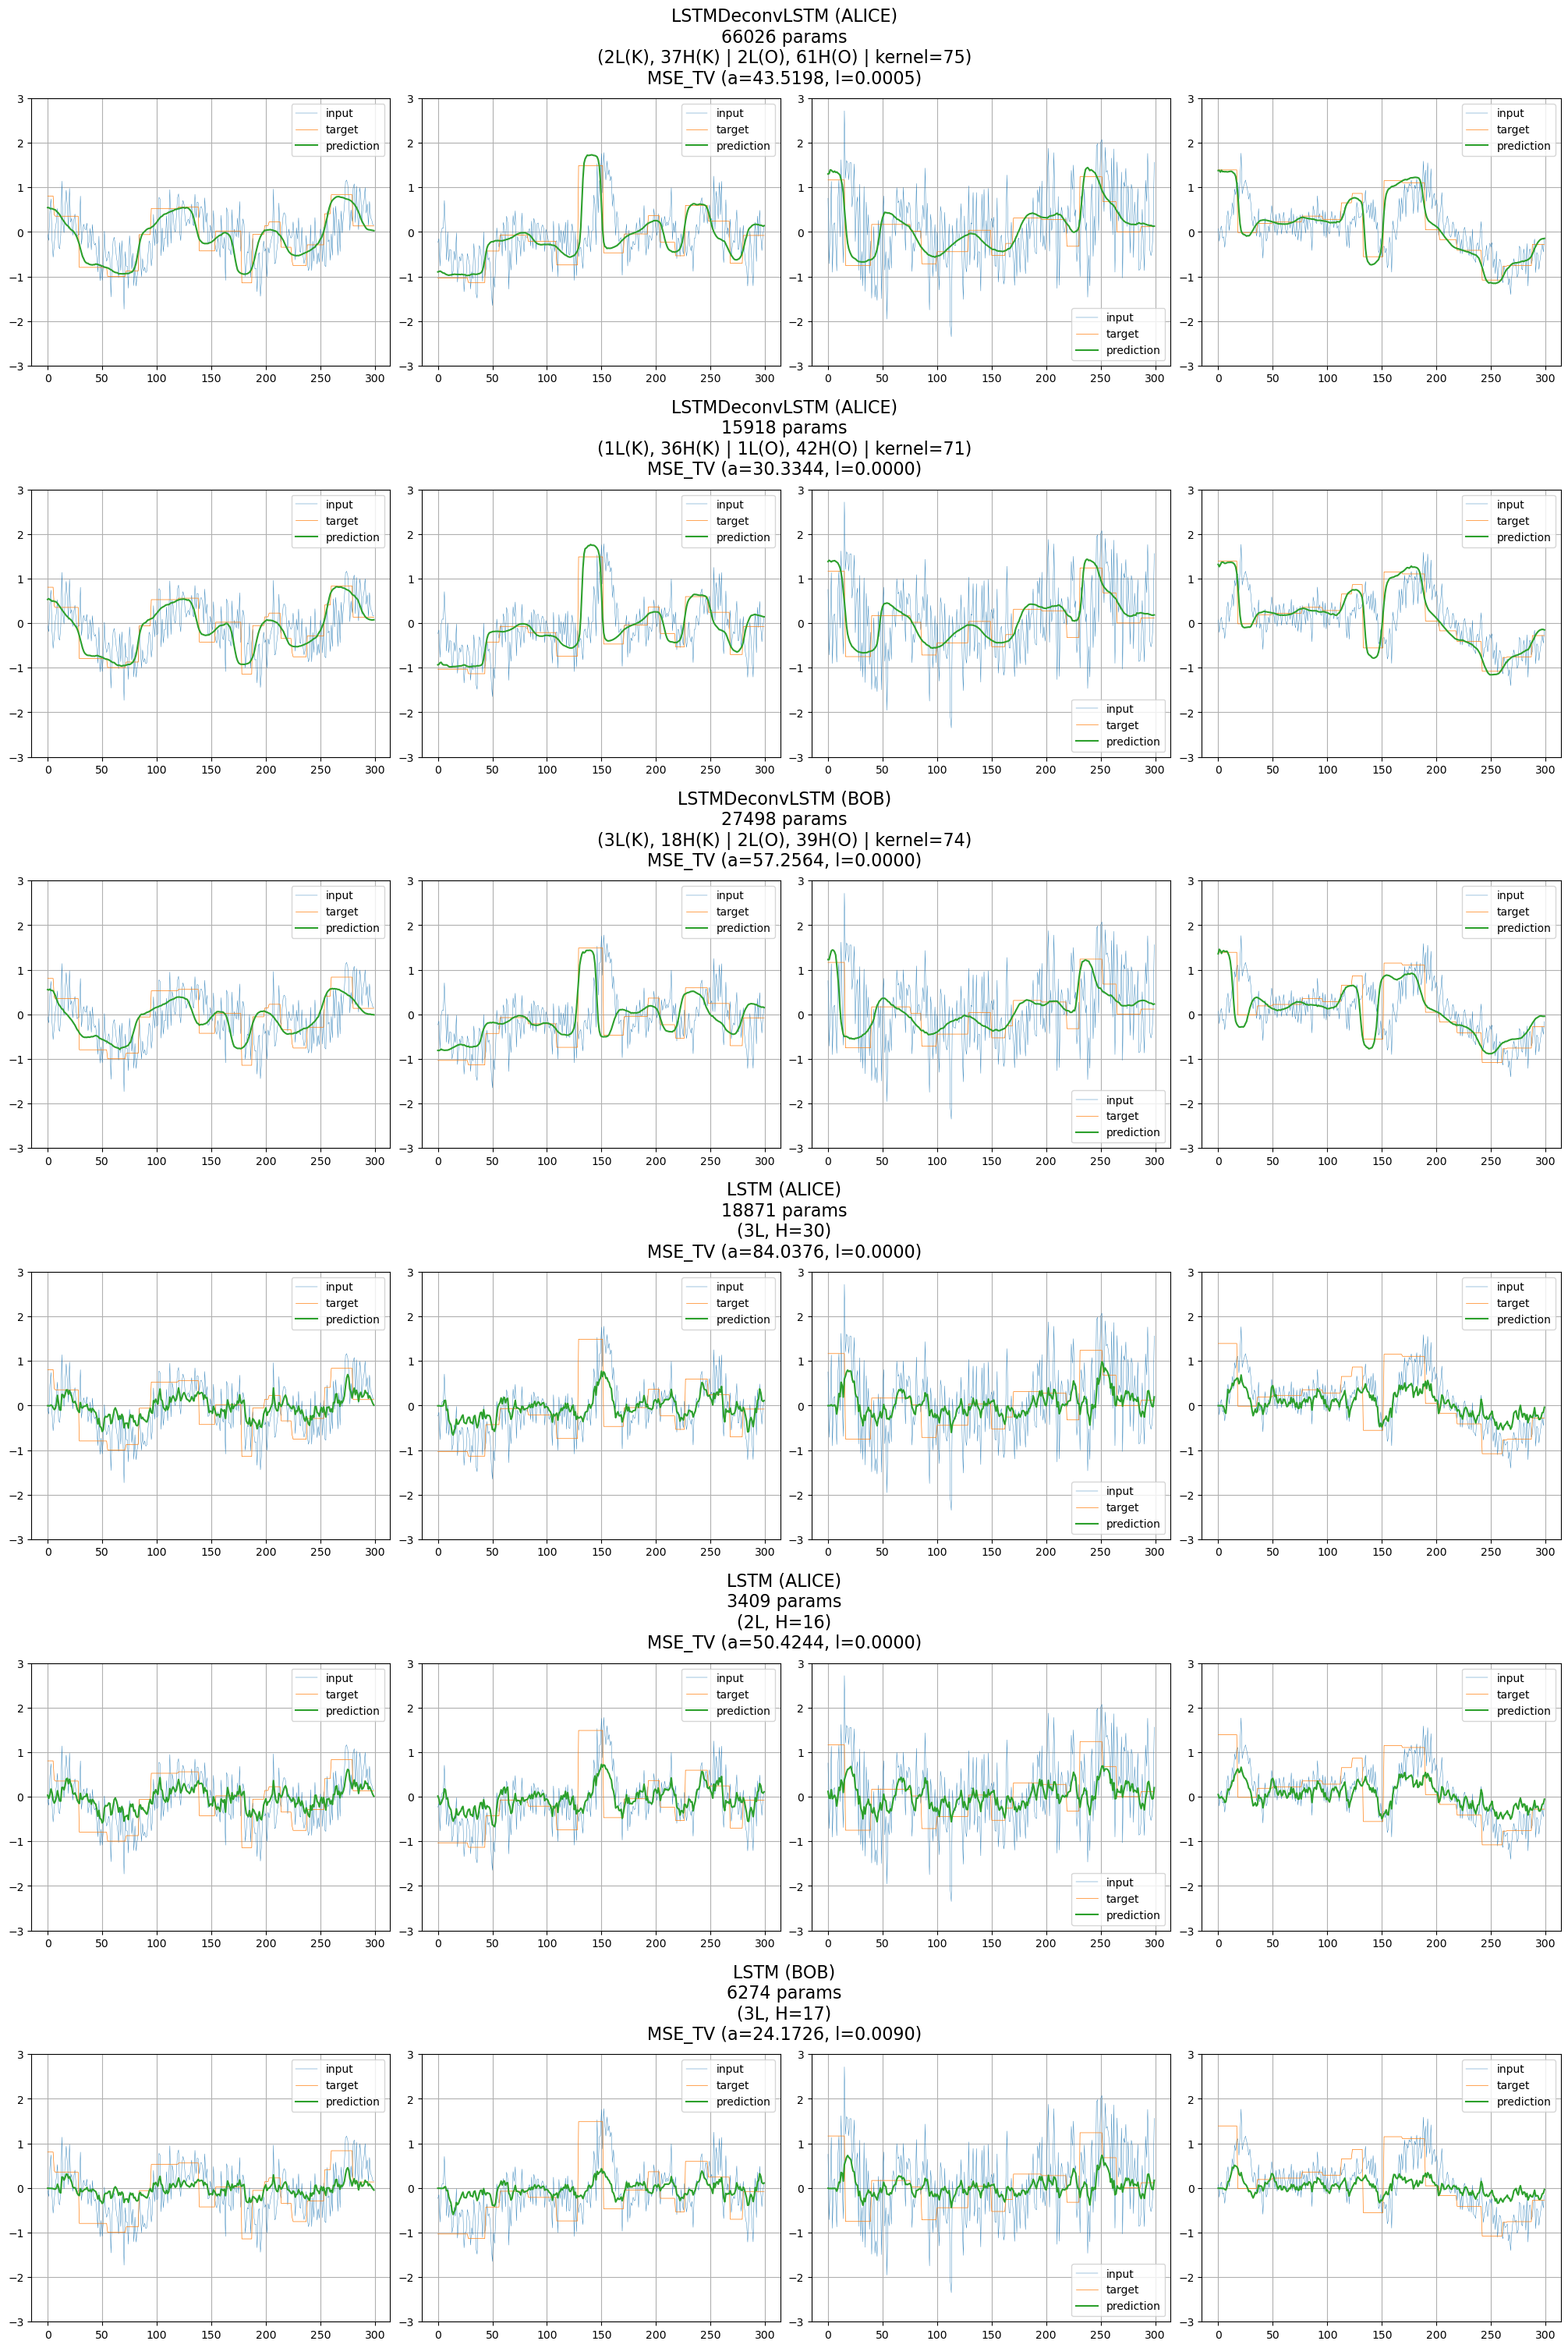

In [17]:
results_lstm = {}
results_lstm['loss_plot'], results_lstm['inference_plot'], results_lstm['df_test_mse'] = analyse_hp_search(results_df, sim_test_dataset)